# 🎓 Signals of Disengagement: A Data Mining Study
## Mining User Engagement Patterns for Early Warning of Disengagement and Feature Abandonment

---

**Author:** Tanvi Gupta (230911122)  
**Guided by:** Dr. Satyajit Mahapatra & Dr. Kaliraj S  
**Institution:** Manipal Institute of Technology, Manipal  
**Dataset:** Open University Learning Analytics Dataset (OULAD) — `studentVle.csv`  
**Tools:** Python · pandas · NumPy · Matplotlib · Seaborn · scikit-learn

---

## Table of Contents
1. [Problem Definition & Objectives](#1)
2. [Dataset Description & Loading](#2)
3. [Exploratory Data Analysis](#3)
4. [Data Preprocessing](#4)
5. [Feature Engineering](#5)
6. [Early Warning Signal Detection](#6)
7. [Feature Adoption vs Abandonment](#7)
8. [Clustering — K-Means](#8)
9. [Disengagement Risk Scoring](#9)
10. [Results Dashboard](#10)
11. [Conclusions & Future Work](#11)

In [1]:
# ── CELL 1: Import libraries ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#f9f9f9', 'axes.facecolor': '#ffffff',
    'axes.grid': True, 'grid.alpha': 0.35,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

PALETTE        = sns.color_palette('Set2')
RED            = '#E74C3C'
GREEN          = '#2ECC71'
BLUE           = '#2980B9'
ORANGE         = '#E67E22'
CLUSTER_COLORS = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']
STATUS_COLORS  = {'Abandoned': '#E74C3C', 'Declining': '#E67E22',
                  'Adopted': '#27AE60',   'Growing':   '#2980B9'}
RISK_COLORS    = {'Low Risk': '#2ECC71', 'Moderate Risk': '#E67E22', 'High Risk': '#E74C3C'}

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")
print("All libraries loaded successfully.")

pandas 2.3.3 | numpy 2.3.5 | seaborn 0.13.2
All libraries loaded successfully.


---
<a id='2'></a>
## 2. Dataset Description & Loading

### About OULAD — `studentVle.csv`

| Column | Type | Description |
|--------|------|-------------|
| `code_module` | str | Course module code (e.g. AAA, BBB) |
| `code_presentation` | str | Year + semester (e.g. 2013J) |
| `id_student` | int | Anonymised student ID |
| `id_site` | int | VLE activity / resource ID |
| `date` | int | Day relative to course start (negative = pre-course access) |
| `sum_click` | int | Total clicks by that student on that resource on that day |

> **Note on `date`:** Day 0 = course start. Negative dates are pre-course engagement.

In [2]:
# ── CELL 2: Load dataset ─────────────────────────────────────────────────────
# sep=None + engine='python' auto-detects comma / tab / space separator
data = pd.read_csv("studentVle.csv", sep=None, engine='python')

EXPECTED = {'code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click'} 
assert EXPECTED.issubset(set(data.columns)), f"Missing columns! Found: {data.columns.tolist()}"

print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Rows              : {len(data):,}")
print(f"  Columns           : {data.shape[1]}  →  {data.columns.tolist()}")
print(f"  Unique students   : {data['id_student'].nunique():,}")
print(f"  Unique VLE sites  : {data['id_site'].nunique():,}")
print(f"  Modules           : {data['code_module'].unique().tolist()}")
print(f"  Presentations     : {data['code_presentation'].unique().tolist()}")
print(f"  Date range        : day {data['date'].min()} to day {data['date'].max()}")
print(f"  sum_click range   : {data['sum_click'].min()} to {data['sum_click'].max()}")
print(f"  Total clicks      : {data['sum_click'].sum():,}")
print("=" * 60)
data.head(10)

  DATASET OVERVIEW
  Rows              : 10,655,280
  Columns           : 6  →  ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
  Unique students   : 26,074
  Unique VLE sites  : 6,268
  Modules           : ['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']
  Presentations     : ['2013J', '2014J', '2013B', '2014B']
  Date range        : day -25 to day 269
  sum_click range   : 1 to 6977
  Total clicks      : 39,605,099


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1
5,AAA,2013J,28400,546652,-10,8
6,AAA,2013J,28400,546876,-10,2
7,AAA,2013J,28400,546688,-10,15
8,AAA,2013J,28400,546662,-10,17
9,AAA,2013J,28400,546890,-10,1


In [3]:
# ── CELL 3: Data types and statistics ────────────────────────────────────────
print("Column data types:")
display(data.dtypes.to_frame('dtype'))
print("\nDescriptive statistics:")
display(data.describe().T.round(2))

Column data types:


,dtype
code_module,object
code_presentation,object
id_student,int64
id_site,int64
date,int64
sum_click,int64



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
id_student,10655280.0,733333.57,582705.98,6516.0,507743.0,588236.0,646484.0,2698588.0
id_site,10655280.0,738323.42,131219.62,526721.0,673519.0,730069.0,877030.0,1049562.0
date,10655280.0,95.17,76.07,-25.0,25.0,86.0,156.0,269.0
sum_click,10655280.0,3.72,8.85,1.0,1.0,2.0,3.0,6977.0


---
<a id='3'></a>
## 3. Exploratory Data Analysis (EDA)

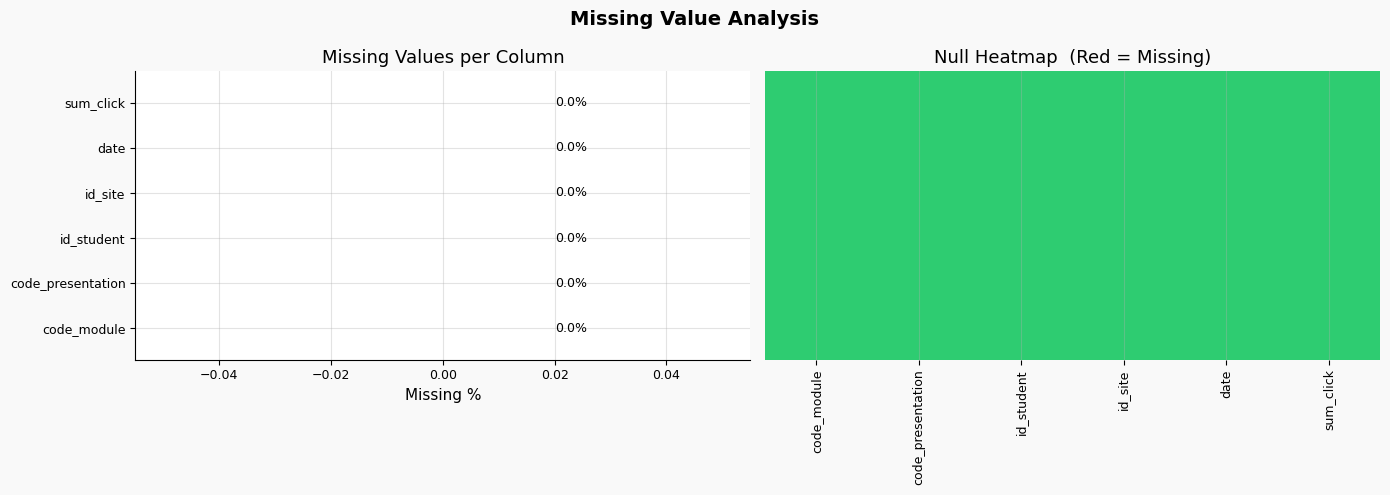

Total missing values: 0


In [4]:
# ── CELL 4: Missing value analysis ───────────────────────────────────────────
missing_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold')

axes[0].barh(missing_pct.index, missing_pct.values,
             color=[RED if v > 0 else GREEN for v in missing_pct.values],
             edgecolor='white')
for i, v in enumerate(missing_pct.values):
    axes[0].text(max(v, 0) + 0.02, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values per Column')

sns.heatmap(data.isnull(), cbar=False, yticklabels=False,
            cmap=[GREEN, RED], ax=axes[1])
axes[1].set_title('Null Heatmap  (Red = Missing)')

plt.tight_layout()
plt.savefig('eda_missing.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Total missing values: {data.isnull().sum().sum()}")

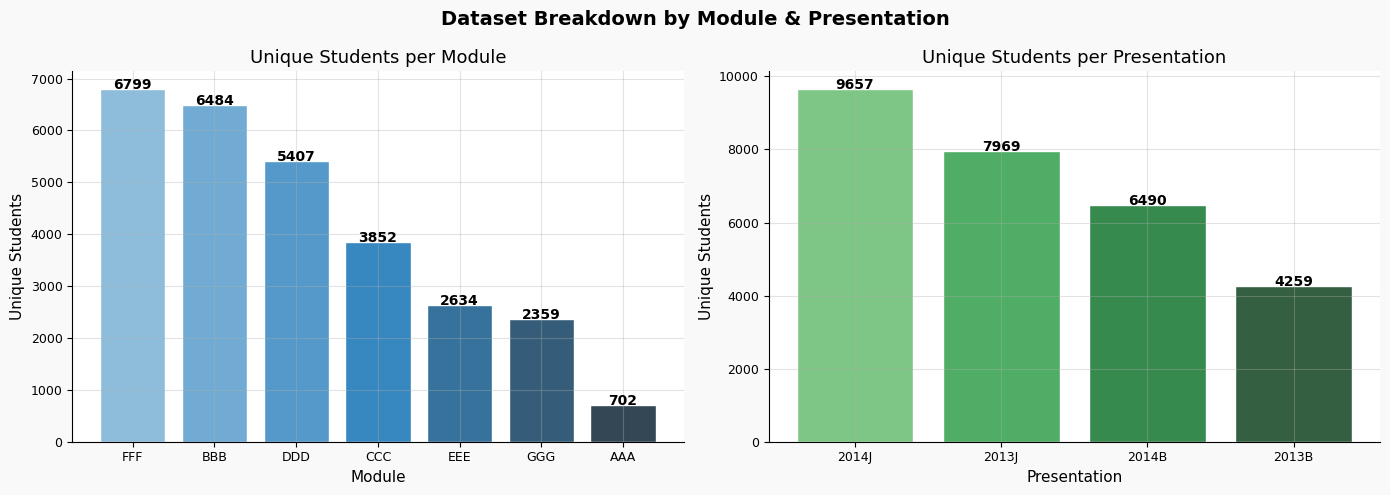

In [5]:
# ── CELL 5: Module and presentation breakdown ────────────────────────────────
mod_counts  = data.groupby('code_module')['id_student'].nunique().sort_values(ascending=False)
pres_counts = data.groupby('code_presentation')['id_student'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Breakdown by Module & Presentation', fontsize=14, fontweight='bold')

axes[0].bar(mod_counts.index, mod_counts.values,
            color=sns.color_palette('Blues_d', len(mod_counts)), edgecolor='white')
axes[0].set_title('Unique Students per Module')
axes[0].set_xlabel('Module')
axes[0].set_ylabel('Unique Students')
for i, v in enumerate(mod_counts.values):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

axes[1].bar(pres_counts.index, pres_counts.values,
            color=sns.color_palette('Greens_d', len(pres_counts)), edgecolor='white')
axes[1].set_title('Unique Students per Presentation')
axes[1].set_xlabel('Presentation')
axes[1].set_ylabel('Unique Students')
for i, v in enumerate(pres_counts.values):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_module_breakdown.png', dpi=120, bbox_inches='tight')
plt.show()

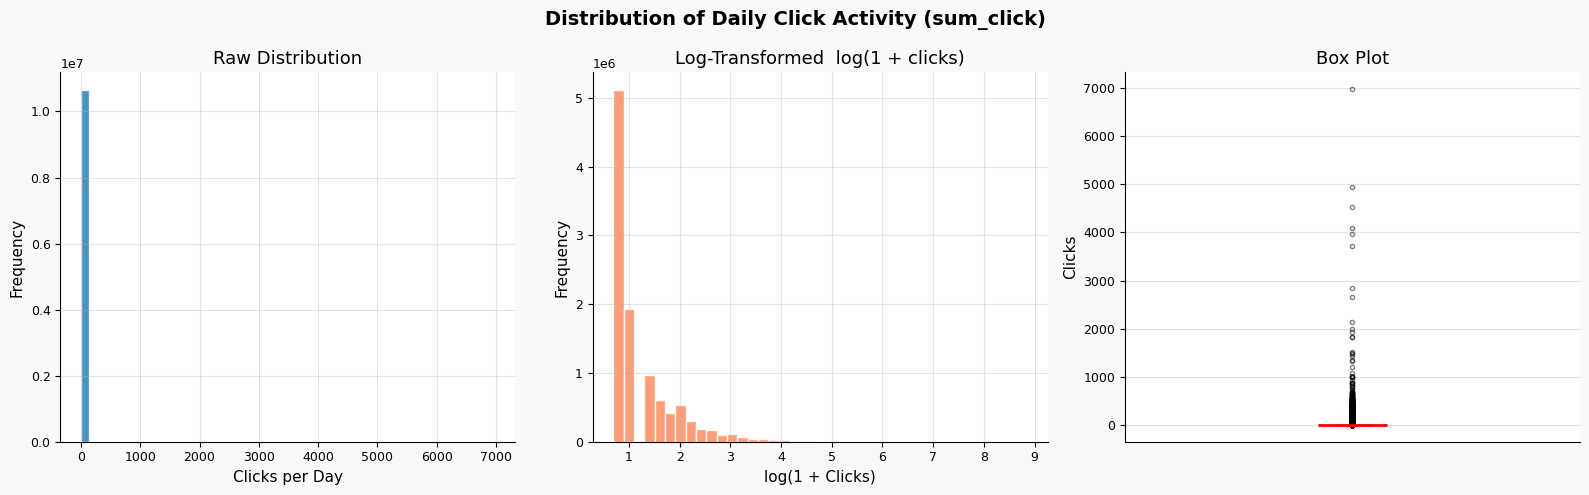

Mean: 3.72  |  Median: 2.00  |  Std: 8.85  |  Skew: 122.92


In [6]:
# ── CELL 6: sum_click distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution of Daily Click Activity (sum_click)', fontsize=14, fontweight='bold')

n_bins_raw = min(50, max(5, len(data) // 2))
axes[0].hist(data['sum_click'], bins=n_bins_raw, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_title('Raw Distribution')
axes[0].set_xlabel('Clicks per Day')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(data['sum_click']), bins=min(40, n_bins_raw),
             color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed  log(1 + clicks)')
axes[1].set_xlabel('log(1 + Clicks)')
axes[1].set_ylabel('Frequency')

axes[2].boxplot(data['sum_click'], patch_artist=True,
                boxprops=dict(facecolor=PALETTE[2], color='gray'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color=RED, markersize=3, alpha=0.5))
axes[2].set_title('Box Plot')
axes[2].set_ylabel('Clicks')
axes[2].set_xticks([])

plt.tight_layout()
plt.savefig('eda_click_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Mean: {data['sum_click'].mean():.2f}  |  Median: {data['sum_click'].median():.2f}"
      f"  |  Std: {data['sum_click'].std():.2f}  |  Skew: {data['sum_click'].skew():.2f}")

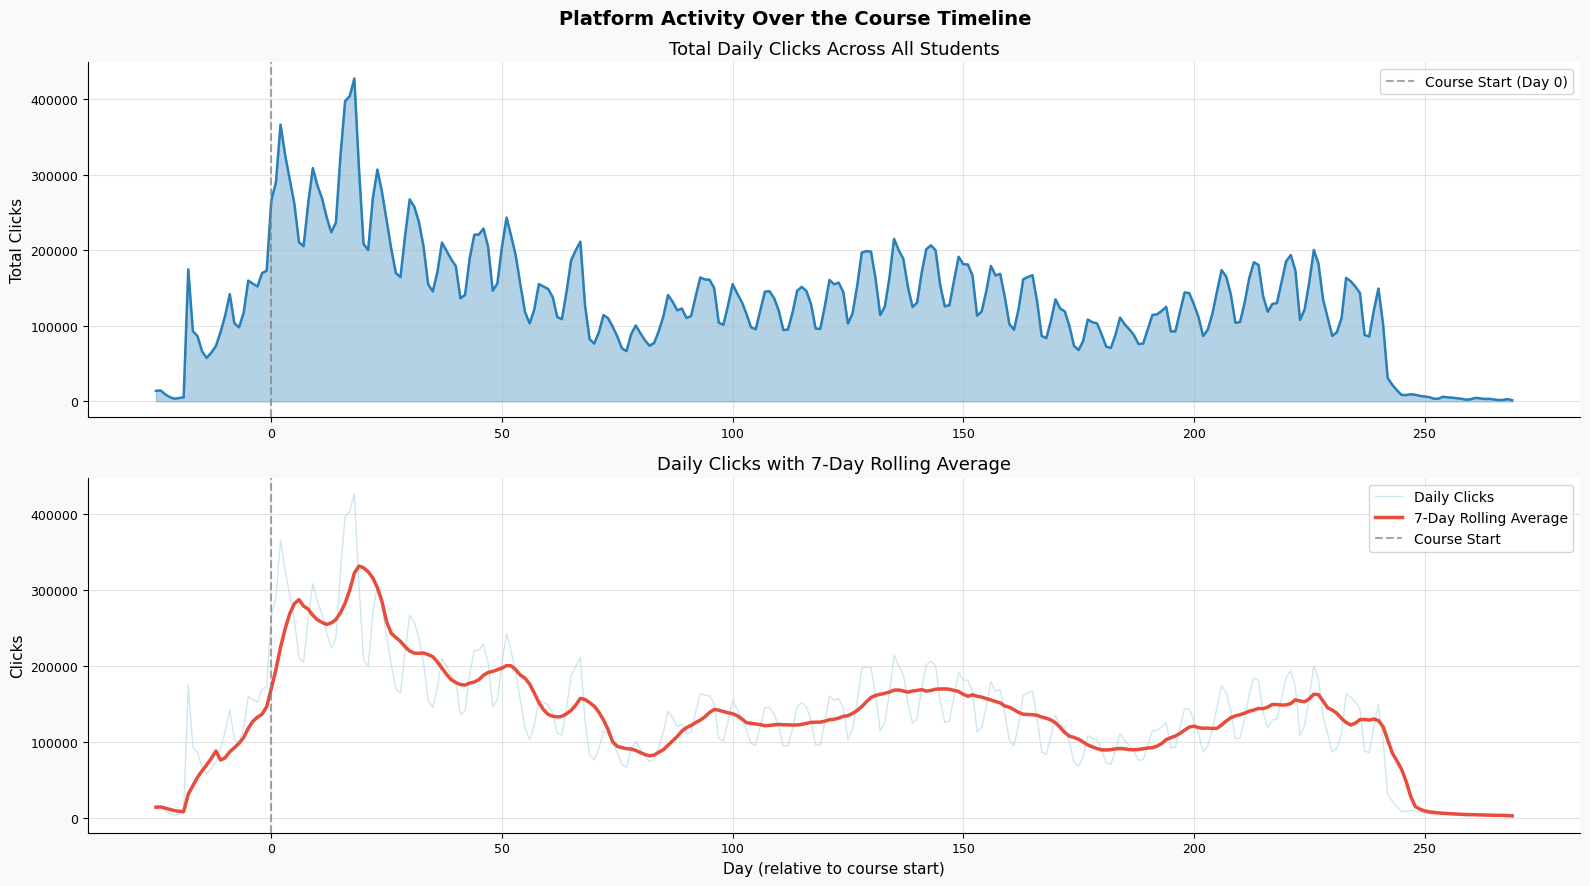

In [7]:
# ── CELL 7: Activity timeline ────────────────────────────────────────────────
daily_total = data.groupby('date')['sum_click'].sum().reset_index()
daily_total['rolling_7'] = daily_total['sum_click'].rolling(7, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Platform Activity Over the Course Timeline', fontsize=14, fontweight='bold')

axes[0].fill_between(daily_total['date'], daily_total['sum_click'], alpha=0.35, color=BLUE)
axes[0].plot(daily_total['date'], daily_total['sum_click'], color=BLUE, linewidth=1.8)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.7, label='Course Start (Day 0)')
axes[0].set_ylabel('Total Clicks')
axes[0].set_title('Total Daily Clicks Across All Students')
axes[0].legend()

axes[1].plot(daily_total['date'], daily_total['sum_click'],
             color='lightblue', linewidth=1, alpha=0.6, label='Daily Clicks')
axes[1].plot(daily_total['date'], daily_total['rolling_7'],
             color=RED, linewidth=2.5, label='7-Day Rolling Average')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.7, label='Course Start')
axes[1].set_xlabel('Day (relative to course start)')
axes[1].set_ylabel('Clicks')
axes[1].set_title('Daily Clicks with 7-Day Rolling Average')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_timeline.png', dpi=120, bbox_inches='tight')
plt.show()

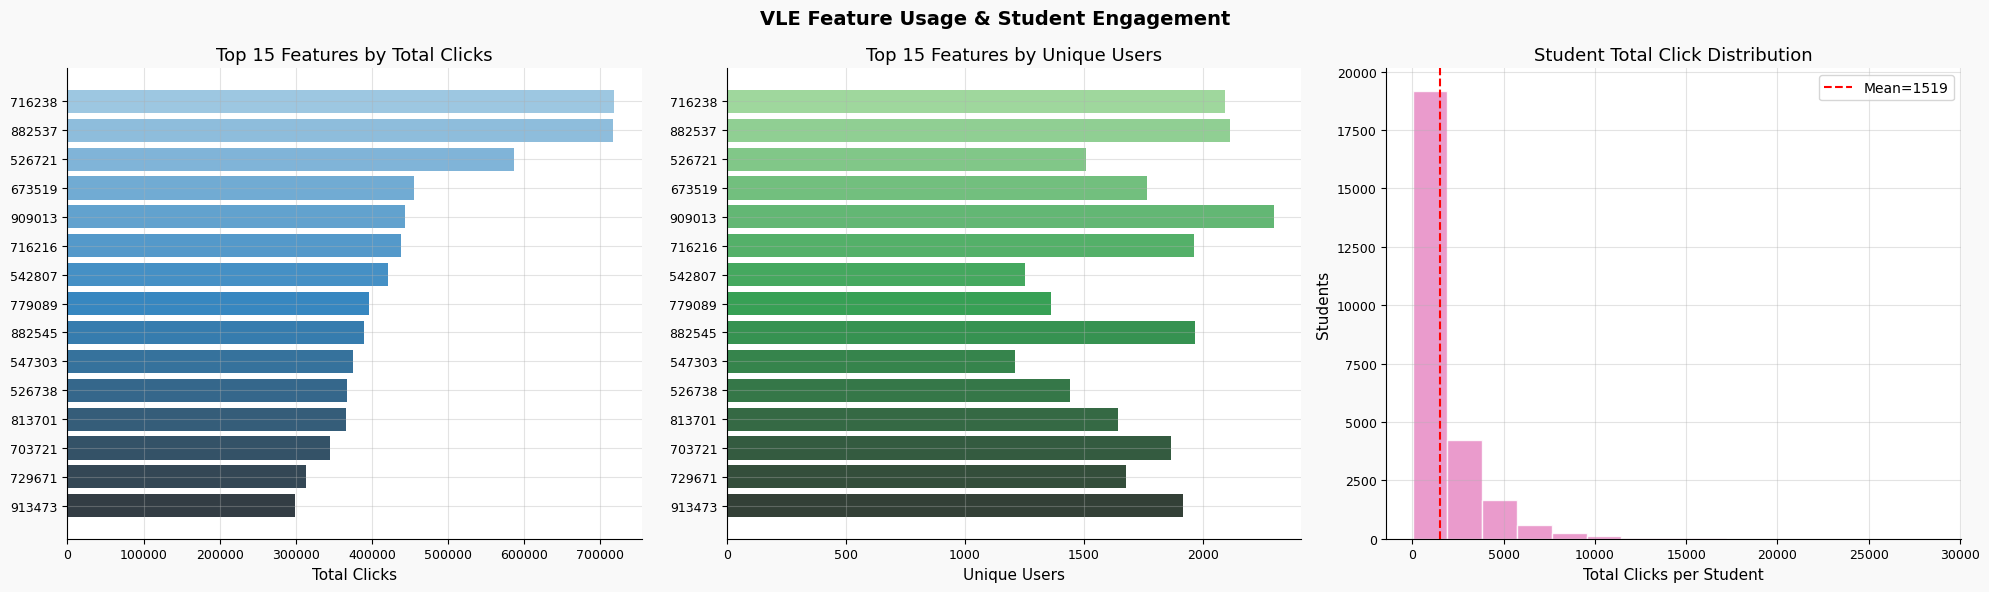

In [8]:
# ── CELL 8: Top VLE features & student engagement ────────────────────────────
site_usage = (data.groupby('id_site')
              .agg(total_clicks=('sum_click', 'sum'),
                   unique_users=('id_student', 'nunique'))
              .reset_index()
              .sort_values('total_clicks', ascending=False))

top_n     = min(15, len(site_usage))
top_sites = site_usage.head(top_n)
student_total = data.groupby('id_student')['sum_click'].sum().reset_index()
student_total.columns = ['id_student', 'total_clicks']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('VLE Feature Usage & Student Engagement', fontsize=14, fontweight='bold')

axes[0].barh(top_sites['id_site'].astype(str), top_sites['total_clicks'],
             color=sns.color_palette('Blues_d', top_n))
axes[0].set_title(f'Top {top_n} Features by Total Clicks')
axes[0].set_xlabel('Total Clicks')
axes[0].invert_yaxis()

axes[1].barh(top_sites['id_site'].astype(str), top_sites['unique_users'],
             color=sns.color_palette('Greens_d', top_n))
axes[1].set_title(f'Top {top_n} Features by Unique Users')
axes[1].set_xlabel('Unique Users')
axes[1].invert_yaxis()

axes[2].hist(student_total['total_clicks'],
             bins=min(15, max(3, len(student_total))),
             color=PALETTE[3], edgecolor='white', alpha=0.85)
if len(student_total) > 1:
    axes[2].axvline(student_total['total_clicks'].mean(), color='red',
                    linestyle='--', label=f'Mean={student_total["total_clicks"].mean():.0f}')
    axes[2].legend()
axes[2].set_title('Student Total Click Distribution')
axes[2].set_xlabel('Total Clicks per Student')
axes[2].set_ylabel('Students')

plt.tight_layout()
plt.savefig('eda_features_students.png', dpi=120, bbox_inches='tight')
plt.show()

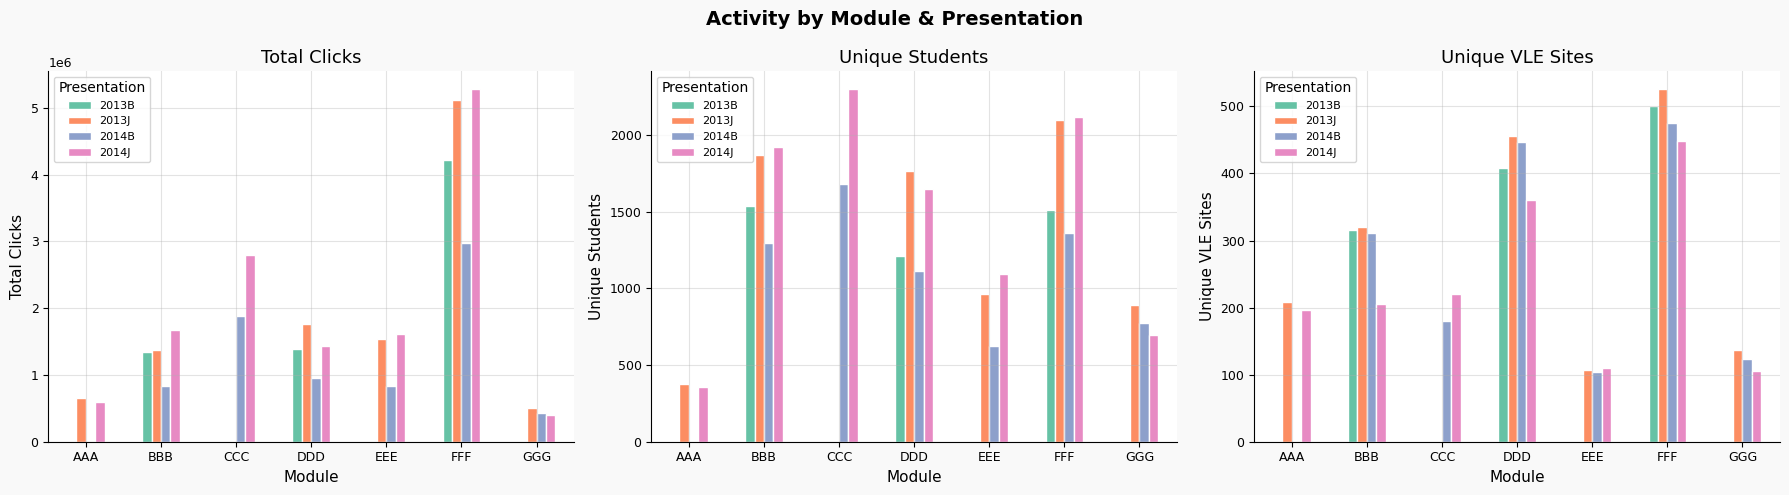

In [9]:
# ── CELL 9: Clicks by module and presentation ────────────────────────────────
mod_pres = (data.groupby(['code_module', 'code_presentation'])
            .agg(total_clicks=('sum_click', 'sum'),
                 unique_students=('id_student', 'nunique'),
                 unique_sites=('id_site', 'nunique'))
            .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Activity by Module & Presentation', fontsize=14, fontweight='bold')

for ax, metric, title in zip(
    axes,
    ['total_clicks', 'unique_students', 'unique_sites'],
    ['Total Clicks', 'Unique Students', 'Unique VLE Sites']
):
    pivot = mod_pres.pivot_table(index='code_module', columns='code_presentation',
                                  values=metric, aggfunc='sum')
    pivot.plot(kind='bar', ax=ax, edgecolor='white',
               color=sns.color_palette('Set2', len(pivot.columns)))
    ax.set_title(title)
    ax.set_xlabel('Module')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Presentation', fontsize=8)

plt.tight_layout()
plt.savefig('eda_module_pres.png', dpi=120, bbox_inches='tight')
plt.show()

---
<a id='4'></a>
## 4. Data Preprocessing

Steps:
1. Remove nulls and duplicate rows
2. Filter zero/negative click records
3. Outlier removal using 3×IQR fence on `sum_click`
4. Temporal transformation: `date` → `week` (shifted so earliest day = week 0)
5. Weekly aggregation per student

In [10]:
# ── CELL 10: Drop nulls, duplicates, and zero-click rows ─────────────────────
print(f"Initial rows      : {len(data):,}")
print(f"Missing values    : {data.isnull().sum().sum()}")
print(f"Duplicate rows    : {data.duplicated().sum():,}")

data_clean    = data.dropna().drop_duplicates()
before_filter = len(data_clean)
data_clean    = data_clean[data_clean['sum_click'] > 0].copy()

print(f"After NaN/dup drop: {before_filter:,}")
print(f"Removed clicks≤0  : {before_filter - len(data_clean):,}")
print(f"Clean rows        : {len(data_clean):,}  ({100*len(data_clean)/len(data):.1f}% retained)")

Initial rows      : 10,655,280
Missing values    : 0
Duplicate rows    : 787,170
After NaN/dup drop: 9,868,110
Removed clicks≤0  : 0
Clean rows        : 9,868,110  (92.6% retained)


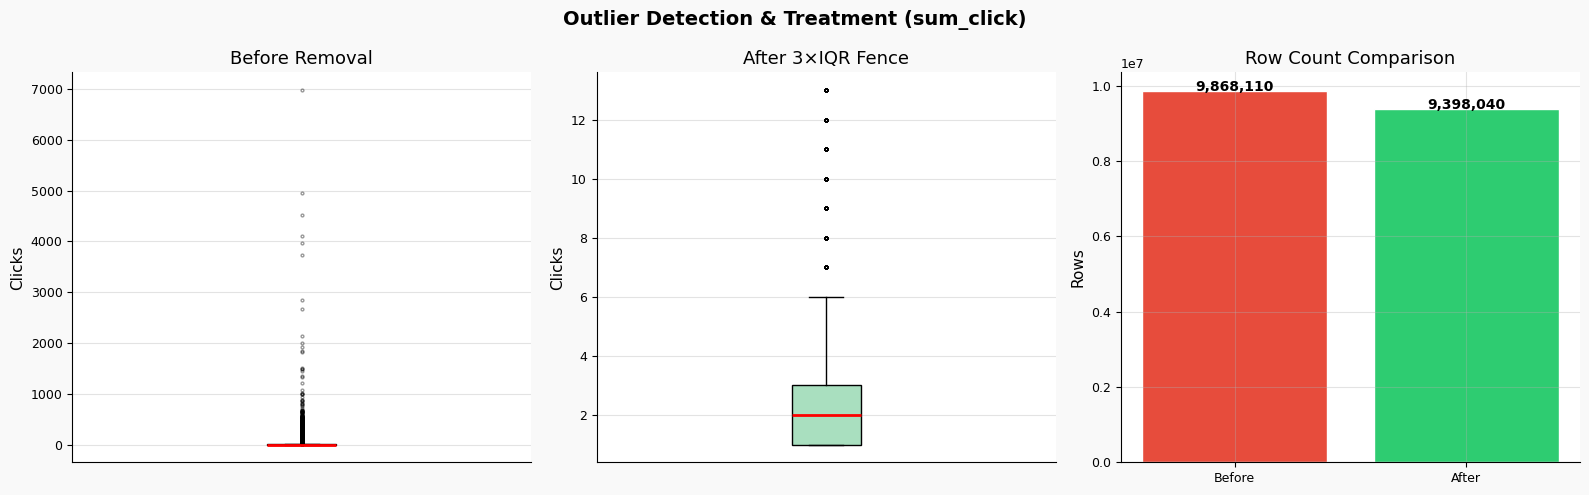

Q1=1.0  Q3=4.0  IQR=3.0  upper fence=13.0
Outliers removed: 470,070  |  Remaining: 9,398,040 rows


In [11]:
# ── CELL 11: Outlier detection and removal (IQR method) ──────────────────────
Q1  = data_clean['sum_click'].quantile(0.25)
Q3  = data_clean['sum_click'].quantile(0.75)
IQR = Q3 - Q1
upper_bound  = Q3 + 3 * IQR          # conservative 3×IQR fence
outlier_mask = data_clean['sum_click'] > upper_bound
n_outliers   = outlier_mask.sum()
before_n     = len(data_clean)
data_clean   = data_clean[~outlier_mask].copy()
after_n      = len(data_clean)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Outlier Detection & Treatment (sum_click)', fontsize=14, fontweight='bold')

for ax, src, label, color in [
    (axes[0], data[data['sum_click']>0]['sum_click'], 'Before Removal',    '#AED6F1'),
    (axes[1], data_clean['sum_click'],                 'After 3×IQR Fence', '#A9DFBF')
]:
    ax.boxplot(src, patch_artist=True,
               boxprops=dict(facecolor=color),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color=RED, markersize=2, alpha=0.4))
    ax.set_title(label)
    ax.set_ylabel('Clicks')
    ax.set_xticks([])

bars = axes[2].bar(['Before', 'After'], [before_n, after_n],
                   color=[RED, GREEN], edgecolor='white')
axes[2].set_title('Row Count Comparison')
axes[2].set_ylabel('Rows')
for bar, val in zip(bars, [before_n, after_n]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('preprocessing_outliers.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  upper fence={upper_bound:.1f}")
print(f"Outliers removed: {n_outliers:,}  |  Remaining: {after_n:,} rows")

In [12]:
# ── CELL 12: Temporal transformation  date → week ────────────────────────────
# Shift dates so the earliest day becomes day 0, then bin into 7-day weeks.
# Works correctly even if the dataset contains only negative (pre-course) dates.
min_date = data_clean['date'].min()
data_clean['day_adjusted'] = data_clean['date'] - min_date
data_clean['week']         = data_clean['day_adjusted'] // 7

print(f"Earliest date in dataset : day {min_date}")
print(f"Adjusted day range       : {data_clean['day_adjusted'].min()} to {data_clean['day_adjusted'].max()}")
print(f"Weeks available          : {data_clean['week'].nunique()}  "
      f"(week {data_clean['week'].min()} to {data_clean['week'].max()})")

Earliest date in dataset : day -25
Adjusted day range       : 0 to 294
Weeks available          : 43  (week 0 to 42)


In [13]:
# ── CELL 13: Weekly aggregation per student ──────────────────────────────────
weekly_activity = (
    data_clean
    .groupby(['id_student', 'code_module', 'code_presentation', 'week'])
    .agg(
        weekly_clicks = ('sum_click',  'sum'),
        active_days   = ('date',       'nunique'),
        features_used = ('id_site',    'nunique'),
    )
    .reset_index()
)

print(f"Weekly aggregation complete.")
print(f"  Rows            : {len(weekly_activity):,}")
print(f"  Unique students : {weekly_activity['id_student'].nunique():,}")
print(f"  Weeks spanned   : {weekly_activity['week'].nunique()}")
display(weekly_activity.head(10))

Weekly aggregation complete.
  Rows            : 629,972
  Unique students : 26,074
  Weeks spanned   : 43


,id_student,code_module,code_presentation,week,weekly_clicks,active_days,features_used
0,6516,AAA,2014J,0,82,3,14
1,6516,AAA,2014J,1,9,2,5
2,6516,AAA,2014J,2,25,2,7
3,6516,AAA,2014J,3,127,5,12
4,6516,AAA,2014J,4,56,4,8
5,6516,AAA,2014J,5,61,5,6
6,6516,AAA,2014J,6,42,4,6
7,6516,AAA,2014J,7,58,5,10
8,6516,AAA,2014J,8,45,4,6
9,6516,AAA,2014J,9,18,4,4


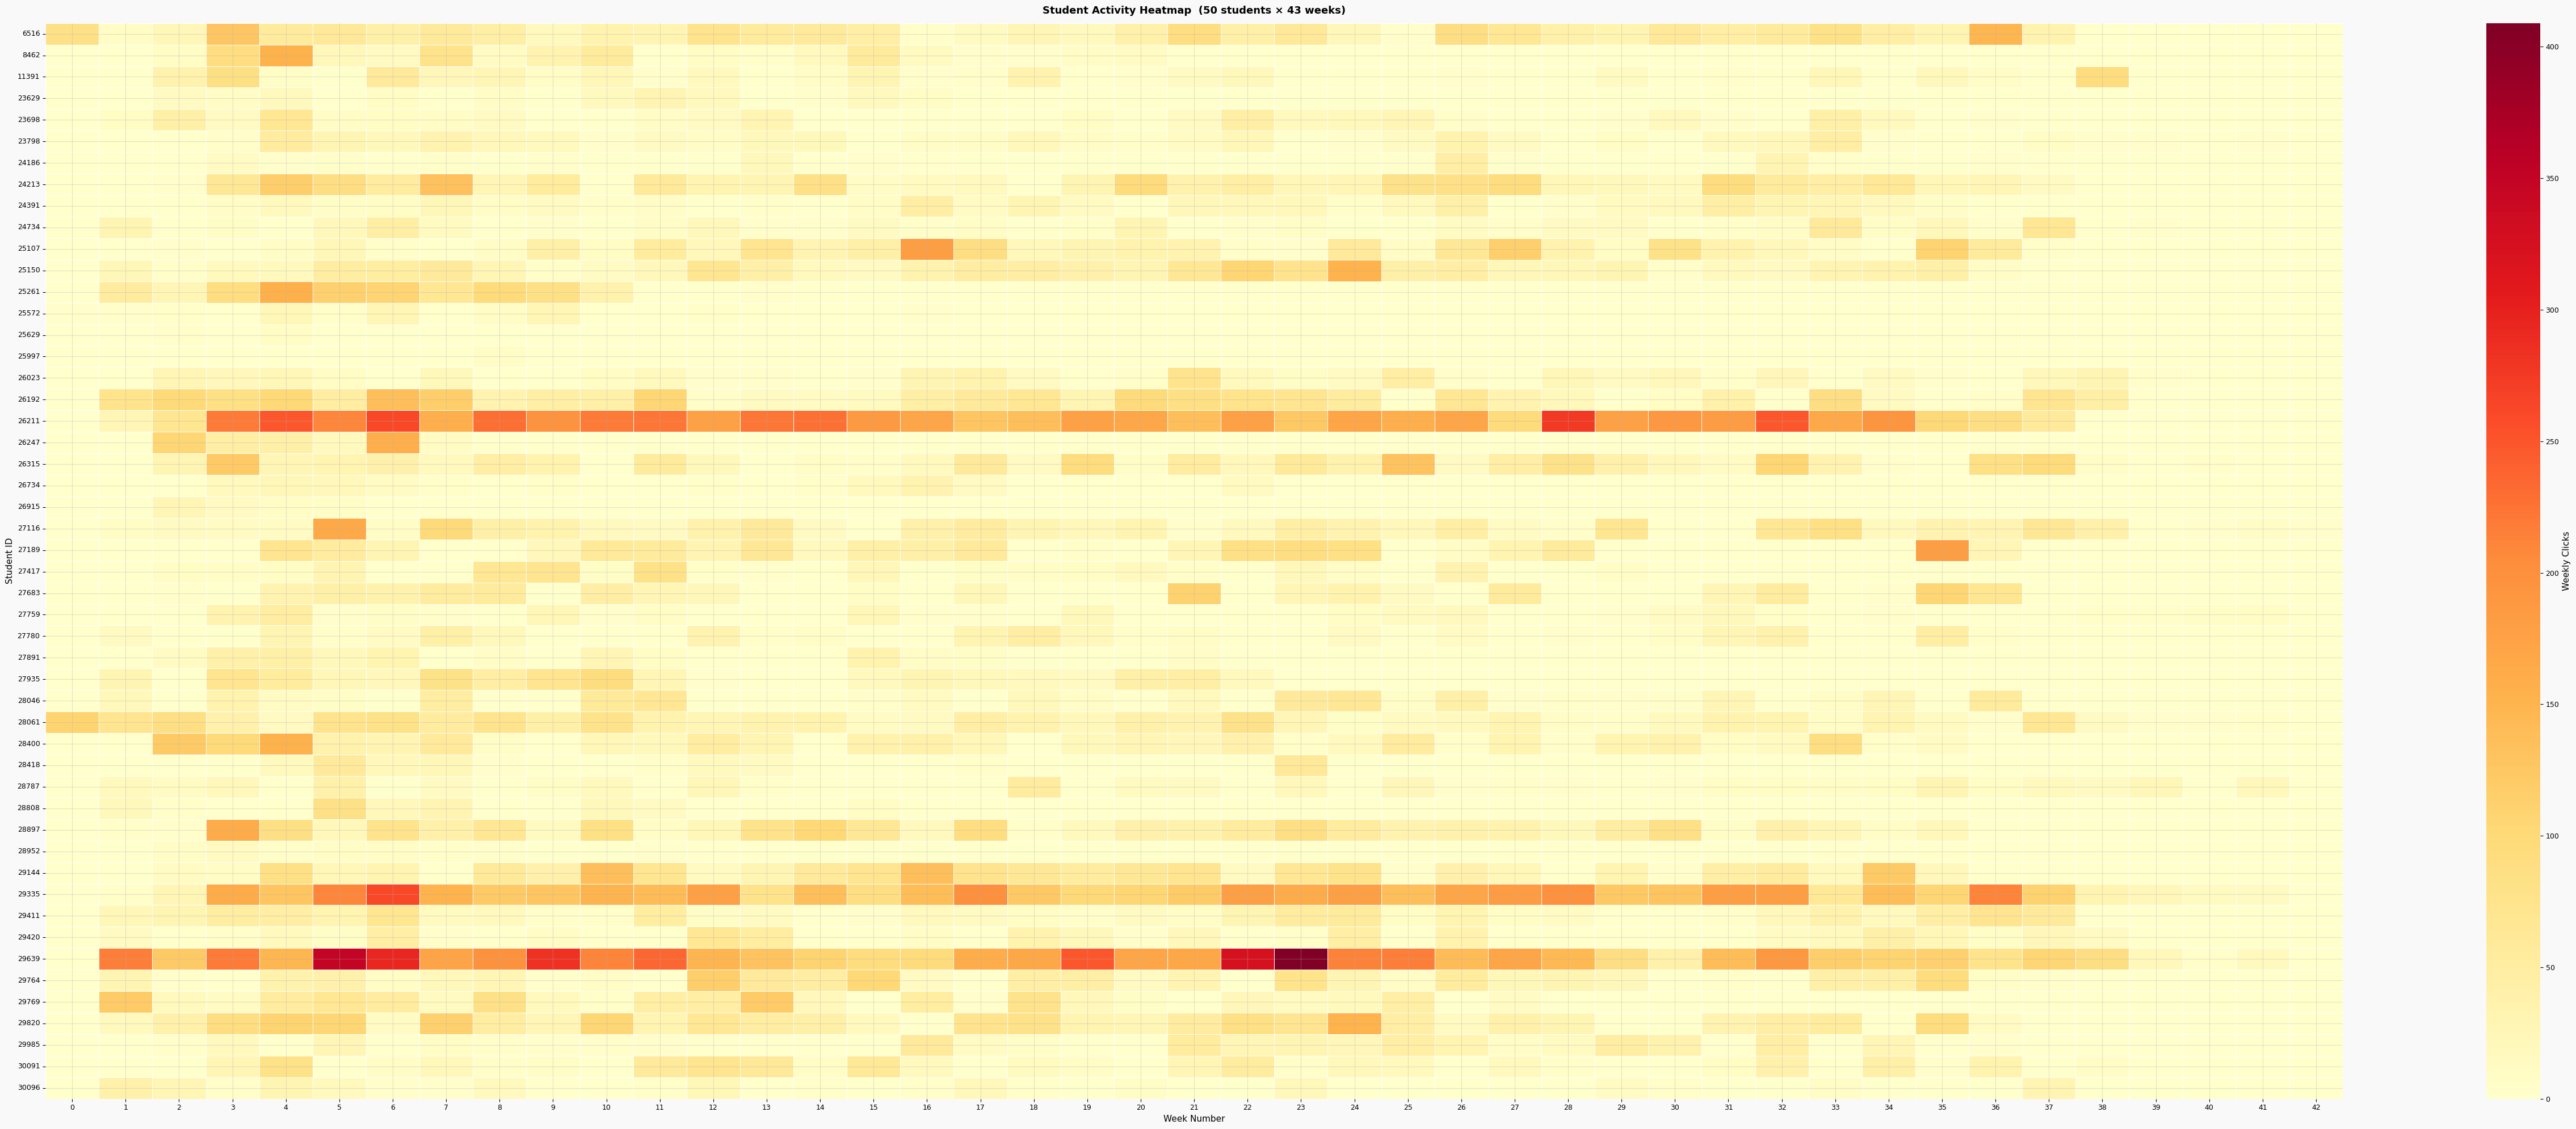

Tip: White/light cells = inactive weeks — key disengagement signal


In [14]:
# ── CELL 14: Student activity heatmap ────────────────────────────────────────
sample_n   = min(50, weekly_activity['id_student'].nunique())
sample_ids = weekly_activity['id_student'].unique()[:sample_n]

pivot = (
    weekly_activity[weekly_activity['id_student'].isin(sample_ids)]
    .pivot_table(index='id_student', columns='week',
                 values='weekly_clicks', aggfunc='sum')
    .fillna(0)
)

fig_w = max(8, len(pivot.columns) * 1.2)
fig_h = max(4, len(pivot) * 0.4)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Weekly Clicks'})
ax.set_title(f'Student Activity Heatmap  ({sample_n} students × {len(pivot.columns)} weeks)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Week Number')
ax.set_ylabel('Student ID')
plt.tight_layout()
plt.savefig('preprocessing_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("Tip: White/light cells = inactive weeks — key disengagement signal")

---
<a id='5'></a>
## 5. Feature Engineering & Construction

Twelve behavioural features per student:

| Feature | Description |
|---------|-------------|
| `avg_weekly_clicks` | Mean clicks per active week |
| `total_clicks` | Total click count |
| `max_weekly_clicks` | Peak single-week activity |
| `std_clicks` | Variance in weekly clicks |
| `active_weeks` | Weeks with any recorded activity |
| `inactivity_weeks` | Weeks with zero activity |
| `engagement_span` | Last active week − first active week |
| `avg_features_per_week` | Mean VLE feature variety per week |
| `avg_active_days` | Mean active days per week |
| `distinct_features_used` | Total unique VLE activities accessed |
| `decay_score` | Linear slope of weekly clicks (negative = declining) |
| `late_engagement_ratio` | Fraction of clicks in last 25% of active weeks |

In [15]:
# ── CELL 15: Build per-student feature matrix ────────────────────────────────
all_weeks = weekly_activity['week'].nunique()

def decay_slope(group):
    """Linear regression slope of weekly_clicks over time. Returns 0 if < 2 data points."""
    if len(group) < 2:
        return 0.0
    x = group['week'].values.astype(float)
    y = group['weekly_clicks'].values.astype(float)
    x = x - x.mean()          # centre to avoid numerical instability
    denom = np.dot(x, x)
    return float(np.dot(x, y) / denom) if denom != 0 else 0.0

def late_ratio(group):
    """Fraction of clicks in the last 25 % of a student's own active weeks."""
    if len(group) < 2:
        return 0.0
    cut   = group['week'].quantile(0.75)
    late  = group.loc[group['week'] >= cut, 'weekly_clicks'].sum()
    total = group['weekly_clicks'].sum()
    return float(late / total) if total > 0 else 0.0

# Core aggregates
features = (
    weekly_activity.groupby('id_student')
    .agg(
        avg_weekly_clicks     = ('weekly_clicks', 'mean'),
        total_clicks          = ('weekly_clicks', 'sum'),
        max_weekly_clicks     = ('weekly_clicks', 'max'),
        std_clicks            = ('weekly_clicks', 'std'),
        active_weeks          = ('week',          'count'),
        avg_features_per_week = ('features_used', 'mean'),
        avg_active_days       = ('active_days',   'mean'),
    )
    .reset_index()
)
features['std_clicks'] = features['std_clicks'].fillna(0)

# Inactivity weeks
inactivity = (
    weekly_activity.groupby('id_student')
    .apply(lambda g: max(0, all_weeks - g['week'].nunique()))
    .reset_index(name='inactivity_weeks')
)
features = features.merge(inactivity, on='id_student', how='left')

# Engagement span
span = (
    weekly_activity.groupby('id_student')
    .apply(lambda g: int(g['week'].max() - g['week'].min()))
    .reset_index(name='engagement_span')
)
features = features.merge(span, on='id_student', how='left')

# Decay score
decay = (
    weekly_activity.groupby('id_student')
    .apply(decay_slope)
    .reset_index(name='decay_score')
)
features = features.merge(decay, on='id_student', how='left')

# Late engagement ratio
late_r = (
    weekly_activity.groupby('id_student')
    .apply(late_ratio)
    .reset_index(name='late_engagement_ratio')
)
features = features.merge(late_r, on='id_student', how='left')

# Distinct features used (breadth of resource access)
breadth = (
    data_clean.groupby('id_student')['id_site']
    .nunique()
    .reset_index(name='distinct_features_used')
)
features = features.merge(breadth, on='id_student', how='left')

print(f"Feature matrix: {features.shape[0]:,} students × {features.shape[1]-1} features")
display(features.describe().T.round(3))

Feature matrix: 26,074 students × 12 features


,count,mean,std,min,25%,50%,75%,max
id_student,26074.0,708745.328,552954.424,6516.0,506717.000,590115.000,645918.250,2698588.000
avg_weekly_clicks,26074.0,33.135,24.251,1.0,17.143,26.504,42.025,262.412
total_clicks,26074.0,946.172,1077.179,1.0,226.250,589.500,1285.000,15321.000
max_weekly_clicks,26074.0,104.294,71.986,1.0,52.000,89.000,142.000,642.000
std_clicks,26074.0,27.303,17.187,0.0,15.263,24.075,36.445,154.216
active_weeks,26074.0,24.161,15.118,1.0,11.000,25.000,34.000,118.000
avg_features_per_week,26074.0,7.671,4.076,1.0,4.778,6.714,9.678,54.200
avg_active_days,26074.0,2.484,1.099,1.0,1.667,2.241,3.074,6.951
inactivity_weeks,26074.0,20.474,12.392,0.0,9.000,19.000,32.000,42.000
engagement_span,26074.0,27.338,12.827,0.0,17.000,34.000,37.000,42.000


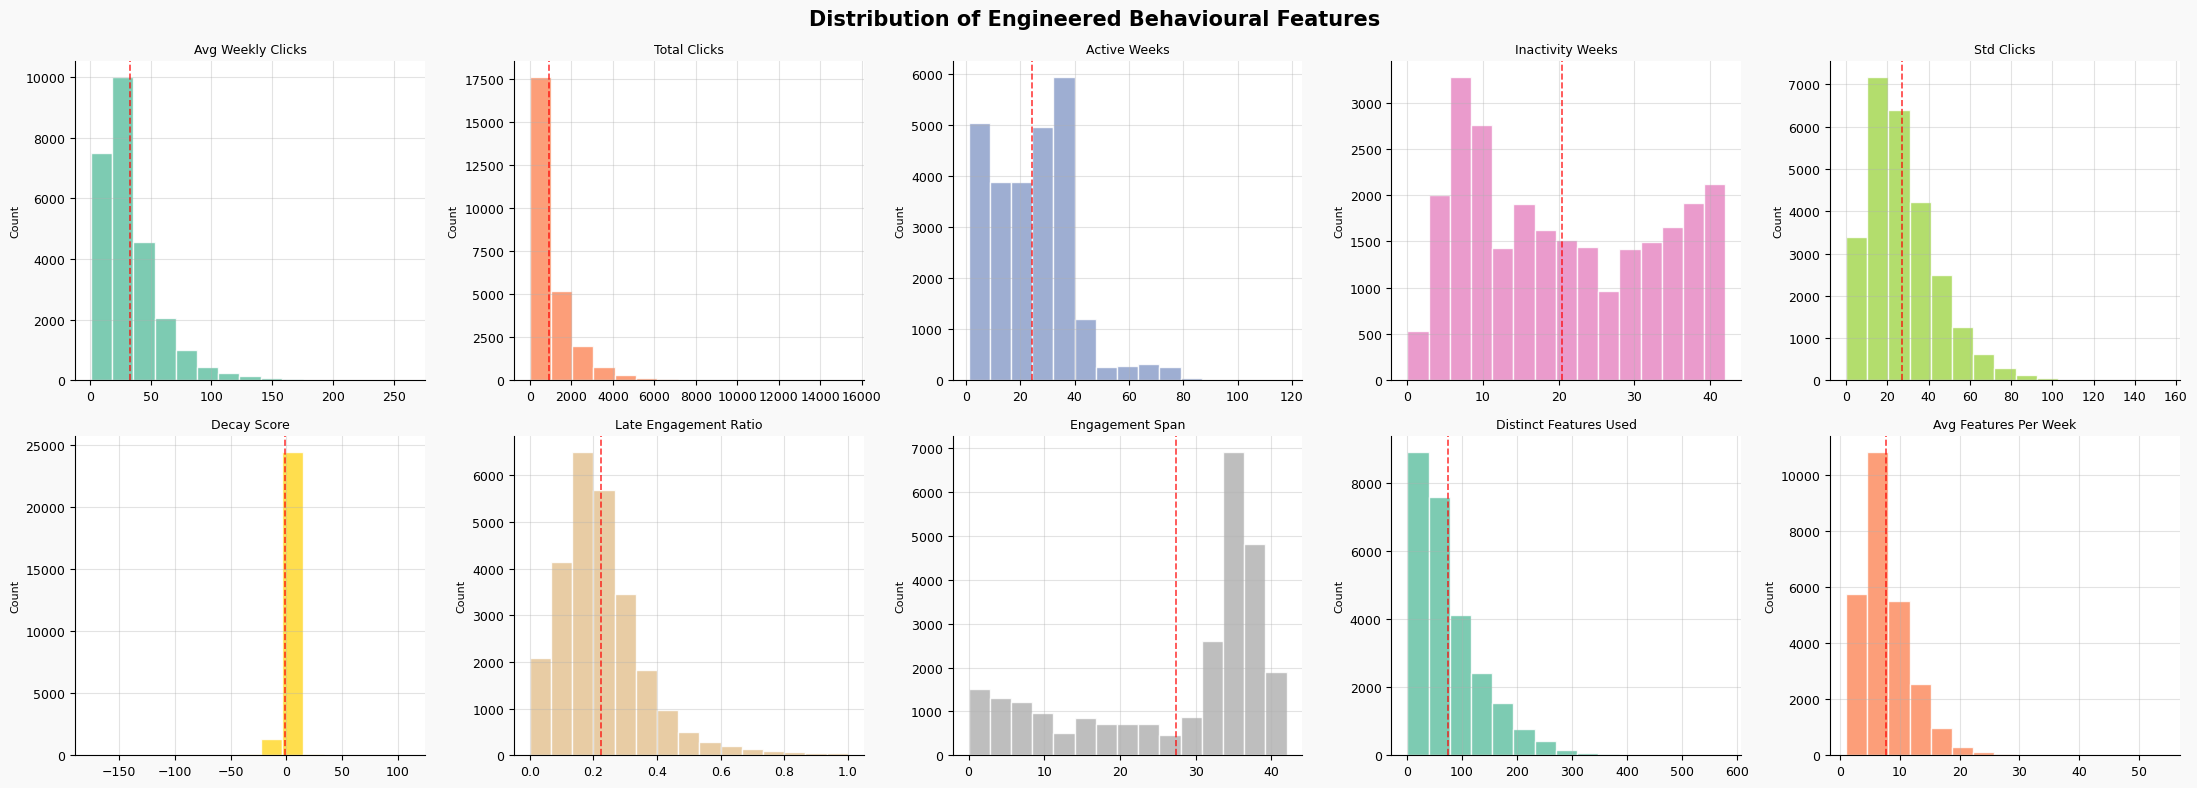

In [16]:
# ── CELL 16: Feature distributions ───────────────────────────────────────────
FEAT_COLS = [
    'avg_weekly_clicks', 'total_clicks', 'active_weeks', 'inactivity_weeks',
    'std_clicks', 'decay_score', 'late_engagement_ratio', 'engagement_span',
    'distinct_features_used', 'avg_features_per_week',
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Distribution of Engineered Behavioural Features', fontsize=15, fontweight='bold')

for idx, col in enumerate(FEAT_COLS):
    ax   = axes[idx // 5][idx % 5]
    vals = features[col].dropna()
    n_bins = min(15, max(3, len(vals)))
    ax.hist(vals, bins=n_bins, color=PALETTE[idx % len(PALETTE)],
            edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=1.2, alpha=0.75)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel('Count', fontsize=8)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

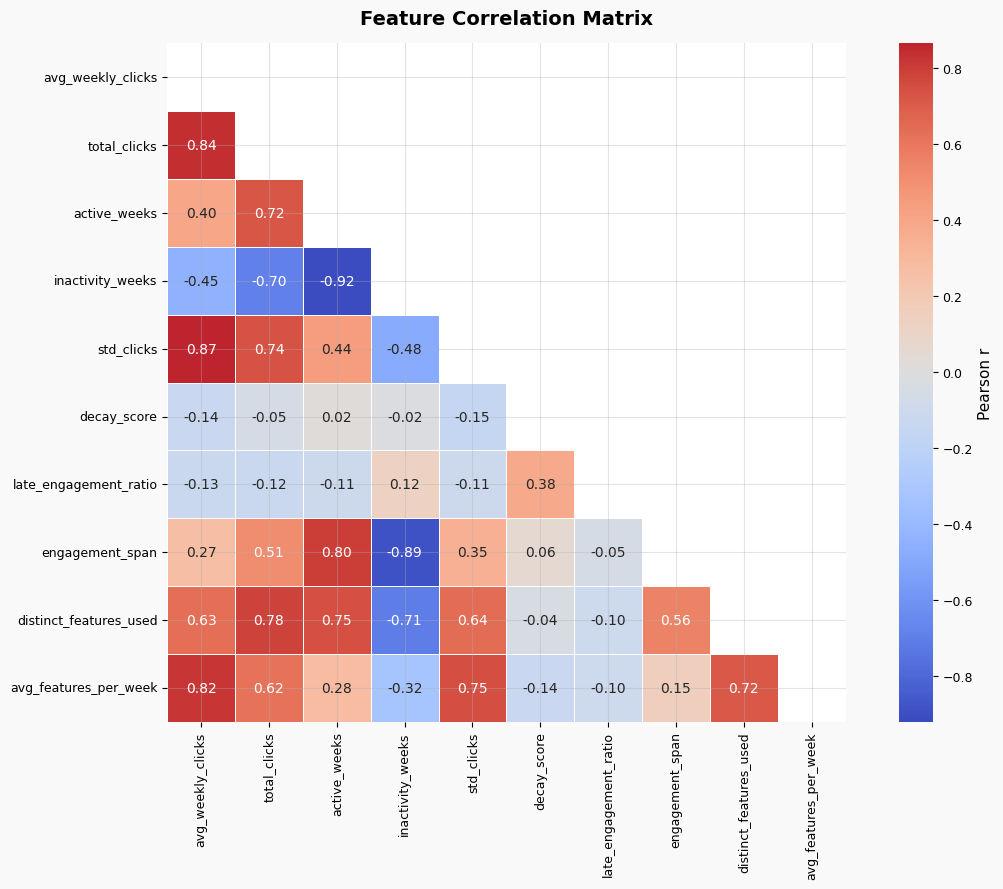

In [17]:
# ── CELL 17: Feature correlation heatmap ─────────────────────────────────────
corr_matrix = features[FEAT_COLS].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

---
<a id='6'></a>
## 6. Early Warning Signal Detection

Students with **high inactivity weeks AND negative engagement decay** are flagged as at-risk.

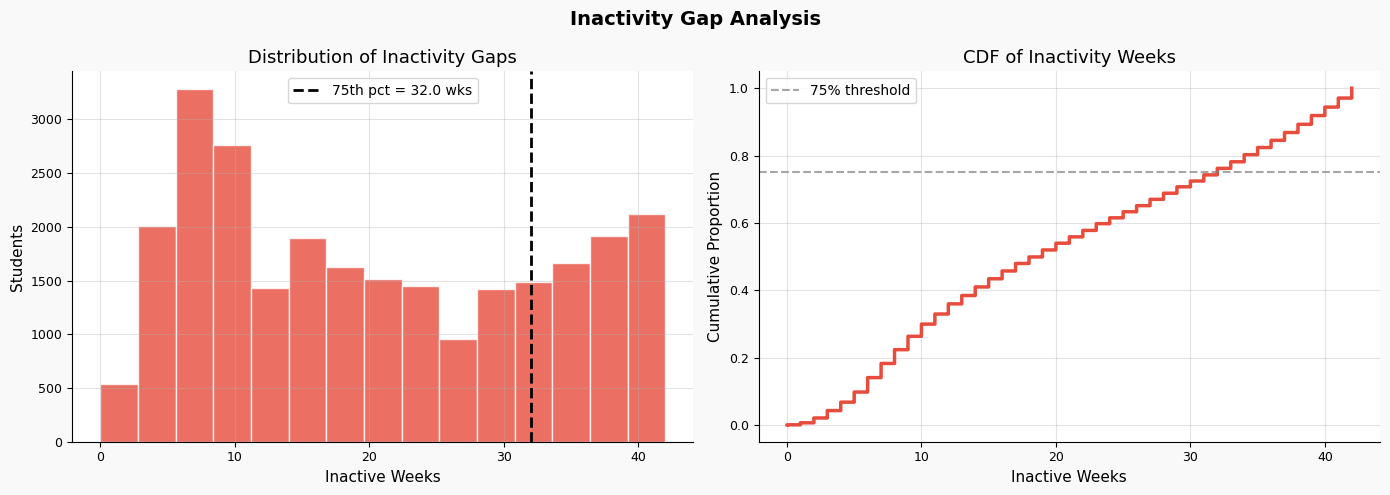

At-Risk Students : 3547  (13.6% of all students)
  Threshold (inactivity_weeks >= 32.0) AND (decay_score < 0)


In [18]:
# ── CELL 18: Inactivity gap analysis + at-risk flagging ──────────────────────
inact_vals      = features['inactivity_weeks']
threshold_inact = (inact_vals.quantile(0.75)
                   if inact_vals.nunique() > 1
                   else inact_vals.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Inactivity Gap Analysis', fontsize=14, fontweight='bold')

axes[0].hist(inact_vals, bins=min(15, inact_vals.nunique() + 1),
             color=RED, edgecolor='white', alpha=0.8)
axes[0].axvline(threshold_inact, color='black', linestyle='--', linewidth=2,
                label=f'75th pct = {threshold_inact:.1f} wks')
axes[0].set_xlabel('Inactive Weeks')
axes[0].set_ylabel('Students')
axes[0].set_title('Distribution of Inactivity Gaps')
axes[0].legend()

sorted_inact = np.sort(inact_vals)
cdf          = np.arange(1, len(sorted_inact) + 1) / len(sorted_inact)
axes[1].step(sorted_inact, cdf, color=RED, linewidth=2.5)
axes[1].axhline(0.75, linestyle='--', color='gray', alpha=0.7, label='75% threshold')
axes[1].set_xlabel('Inactive Weeks')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('CDF of Inactivity Weeks')
axes[1].legend()

plt.tight_layout()
plt.savefig('inactivity_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

features['at_risk'] = (
    (features['inactivity_weeks'] >= threshold_inact) &
    (features['decay_score'] < 0)
).astype(int)

n_risk = features['at_risk'].sum()
print(f"At-Risk Students : {n_risk}  ({100*n_risk/len(features):.1f}% of all students)")
print(f"  Threshold (inactivity_weeks >= {threshold_inact:.1f}) AND (decay_score < 0)")

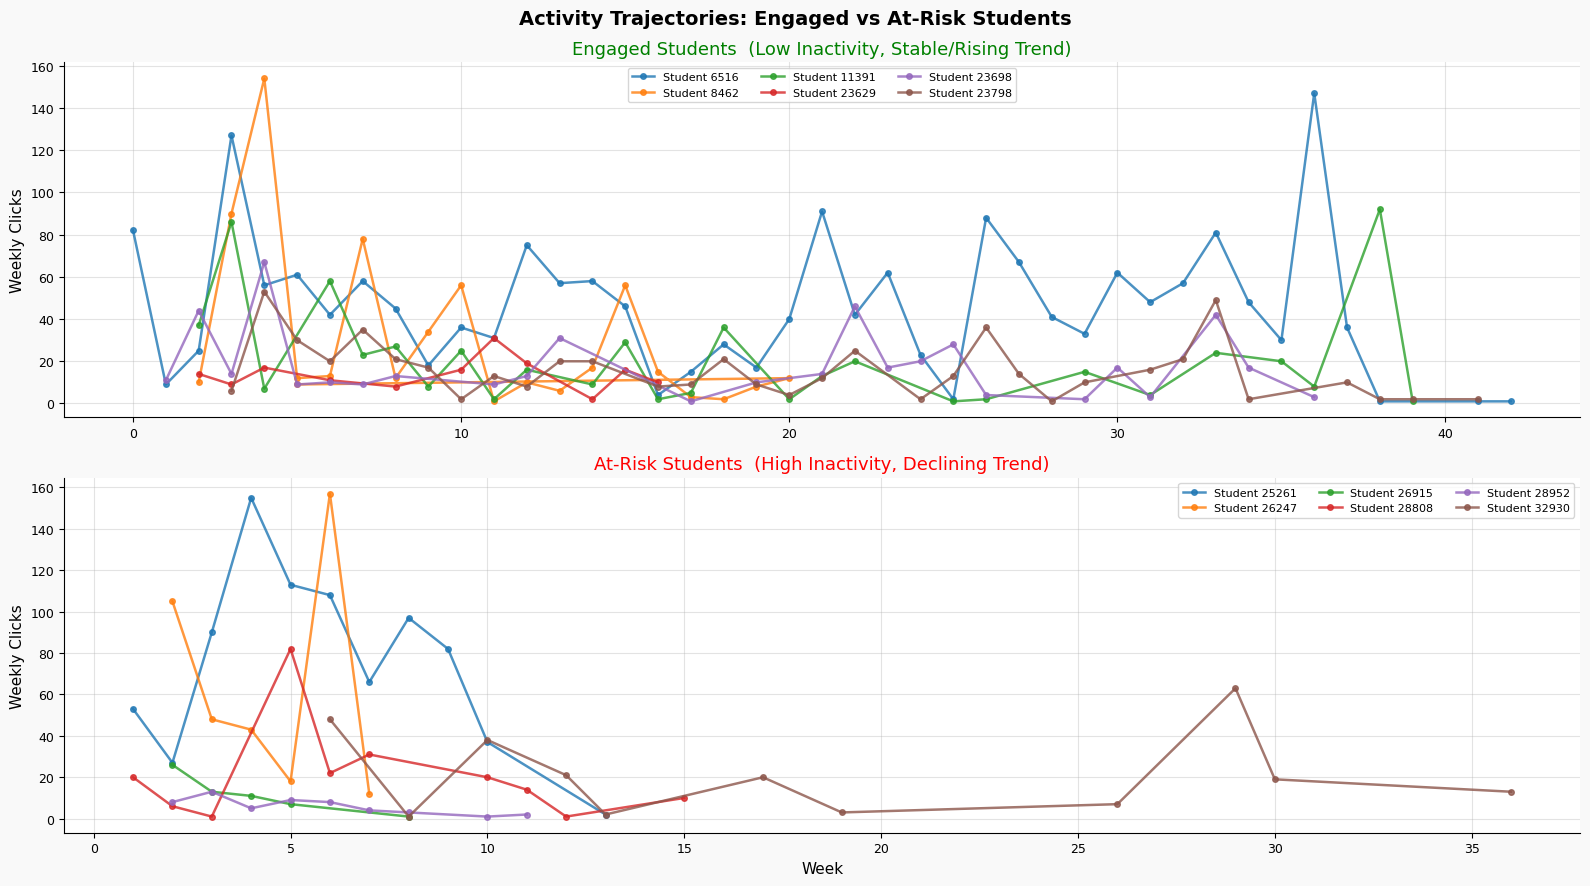

In [19]:
# ── CELL 19: Activity trajectory comparison ──────────────────────────────────
engaged_ids    = features[features['at_risk'] == 0]['id_student'].values
disengaged_ids = features[features['at_risk'] == 1]['id_student'].values
n_show         = min(6, len(engaged_ids), len(disengaged_ids))

if n_show == 0:
    print("Note: With this data slice all students fall in the same risk group.")
    print(f"  Engaged   : {len(engaged_ids)} students")
    print(f"  At-Risk   : {len(disengaged_ids)} students")
    print("  (Trajectory comparison requires students in both groups.)")
    print("  When running on the full OULAD dataset both groups will be populated.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    fig.suptitle('Activity Trajectories: Engaged vs At-Risk Students',
                 fontsize=14, fontweight='bold')

    for uid in engaged_ids[:n_show]:
        u = weekly_activity[weekly_activity['id_student'] == uid]
        axes[0].plot(u['week'], u['weekly_clicks'],
                     marker='o', markersize=4, linewidth=1.8, alpha=0.8,
                     label=f'Student {uid}')
    axes[0].set_title('Engaged Students  (Low Inactivity, Stable/Rising Trend)',
                      color='green')
    axes[0].set_ylabel('Weekly Clicks')
    axes[0].legend(fontsize=8, ncol=3)

    for uid in disengaged_ids[:n_show]:
        u = weekly_activity[weekly_activity['id_student'] == uid]
        axes[1].plot(u['week'], u['weekly_clicks'],
                     marker='o', markersize=4, linewidth=1.8, alpha=0.8,
                     label=f'Student {uid}')
    axes[1].set_title('At-Risk Students  (High Inactivity, Declining Trend)', color='red')
    axes[1].set_ylabel('Weekly Clicks')
    axes[1].set_xlabel('Week')
    axes[1].legend(fontsize=8, ncol=3)

    plt.tight_layout()
    plt.savefig('trajectory_comparison.png', dpi=120, bbox_inches='tight')
    plt.show()

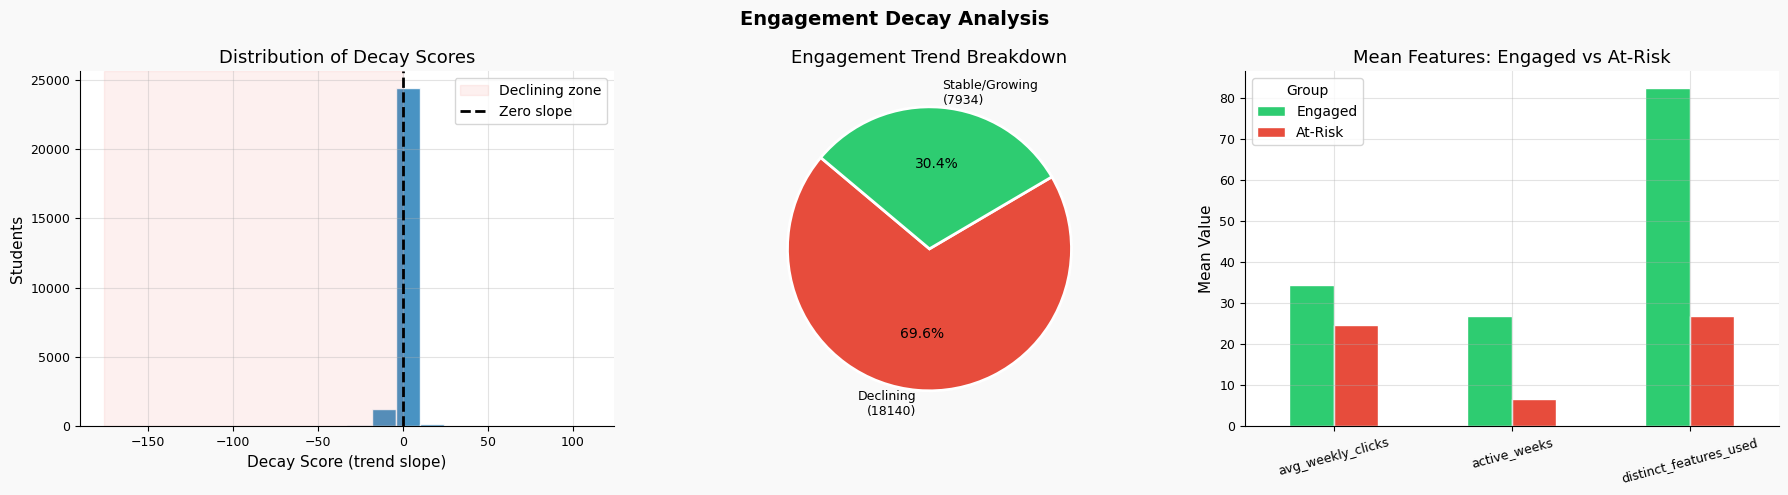

In [20]:
# ── CELL 20: Decay score distribution + group comparison ─────────────────────
n_declining = (features['decay_score'] < 0).sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Engagement Decay Analysis', fontsize=14, fontweight='bold')

# Decay histogram
axes[0].hist(features['decay_score'],
             bins=min(20, max(3, len(features)//2)),
             color=BLUE, edgecolor='white', alpha=0.85)
# shade negative region to highlight disengagement zone
axes[0].axvspan(features['decay_score'].min() - 0.5, 0,
                alpha=0.08, color=RED, label='Declining zone')
axes[0].axvline(0, color='black', linestyle='--', linewidth=2, label='Zero slope')
axes[0].set_xlabel('Decay Score (trend slope)')
axes[0].set_ylabel('Students')
axes[0].set_title('Distribution of Decay Scores')
axes[0].legend()

# Pie chart
axes[1].pie(
    [n_declining, len(features) - n_declining],
    labels=[f'Declining\n({n_declining})',
            f'Stable/Growing\n({len(features)-n_declining})'],
    colors=[RED, GREEN], autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Engagement Trend Breakdown')

# Mean feature comparison — SAFELY rename index to avoid length mismatch crash
compare_feats = ['avg_weekly_clicks', 'active_weeks', 'distinct_features_used']
group_means   = features.groupby('at_risk')[compare_feats].mean()
rename_map    = {0: 'Engaged', 1: 'At-Risk'}          # safe: only present keys renamed
group_means.index = [rename_map[i] for i in group_means.index]
group_means.T.plot(kind='bar', ax=axes[2],
                   color=[GREEN, RED][:len(group_means)], edgecolor='white')
axes[2].set_title('Mean Features: Engaged vs At-Risk')
axes[2].set_ylabel('Mean Value')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(title='Group')

plt.tight_layout()
plt.savefig('decay_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
<a id='7'></a>
## 7. Feature Adoption vs Abandonment Analysis

Which VLE resources are consistently used and which are silently abandoned?

In [21]:
# ── CELL 21: VLE feature-level weekly usage + classification ─────────────────
feature_weekly = (
    data_clean
    .groupby(['id_site', 'week'])
    .agg(user_count=('id_student', 'nunique'),
         total_clicks=('sum_click', 'sum'))
    .reset_index()
)

feature_trend = (
    feature_weekly.groupby('id_site')
    .agg(
        first_week_usage = ('user_count',   'first'),
        last_week_usage  = ('user_count',   'last'),
        avg_usage        = ('user_count',   'mean'),
        peak_usage       = ('user_count',   'max'),
        active_weeks     = ('week',         'count'),
        total_clicks     = ('total_clicks', 'sum'),
    )
    .reset_index()
)

feature_trend['decay_ratio'] = (
    feature_trend['last_week_usage'] /
    (feature_trend['first_week_usage'] + 1e-9)
)

def classify_feature(row):
    if   row['decay_ratio'] < 0.3: return 'Abandoned'
    elif row['decay_ratio'] < 0.7: return 'Declining'
    elif row['decay_ratio'] < 1.2: return 'Adopted'
    else:                          return 'Growing'

feature_trend['status'] = feature_trend.apply(classify_feature, axis=1)

print("VLE Feature Classification:")
print(feature_trend['status'].value_counts().to_string())
display(feature_trend.head(10))

VLE Feature Classification:
status
Abandoned    2603
Adopted      1890
Declining     976
Growing       799


,id_site,first_week_usage,last_week_usage,avg_usage,peak_usage,active_weeks,total_clicks,decay_ratio,status
0,526721,1043,465,967.513514,1363,37,443065,0.445829,Declining
1,526735,861,61,201.432432,861,37,24753,0.070848,Abandoned
2,526737,498,76,234.459459,624,37,104943,0.152610,Abandoned
3,526738,279,116,618.500000,1141,36,286777,0.415771,Declining
4,526739,281,1,98.486486,434,37,18141,0.003559,Abandoned
5,526740,29,5,5.500000,29,34,593,0.172414,Abandoned
6,526741,4,2,95.518519,323,27,15648,0.500000,Declining
7,526742,7,1,116.318182,319,22,14240,0.142857,Abandoned
8,526743,6,1,69.727273,224,22,8258,0.166667,Abandoned
9,526744,11,1,139.352941,349,17,16055,0.090909,Abandoned


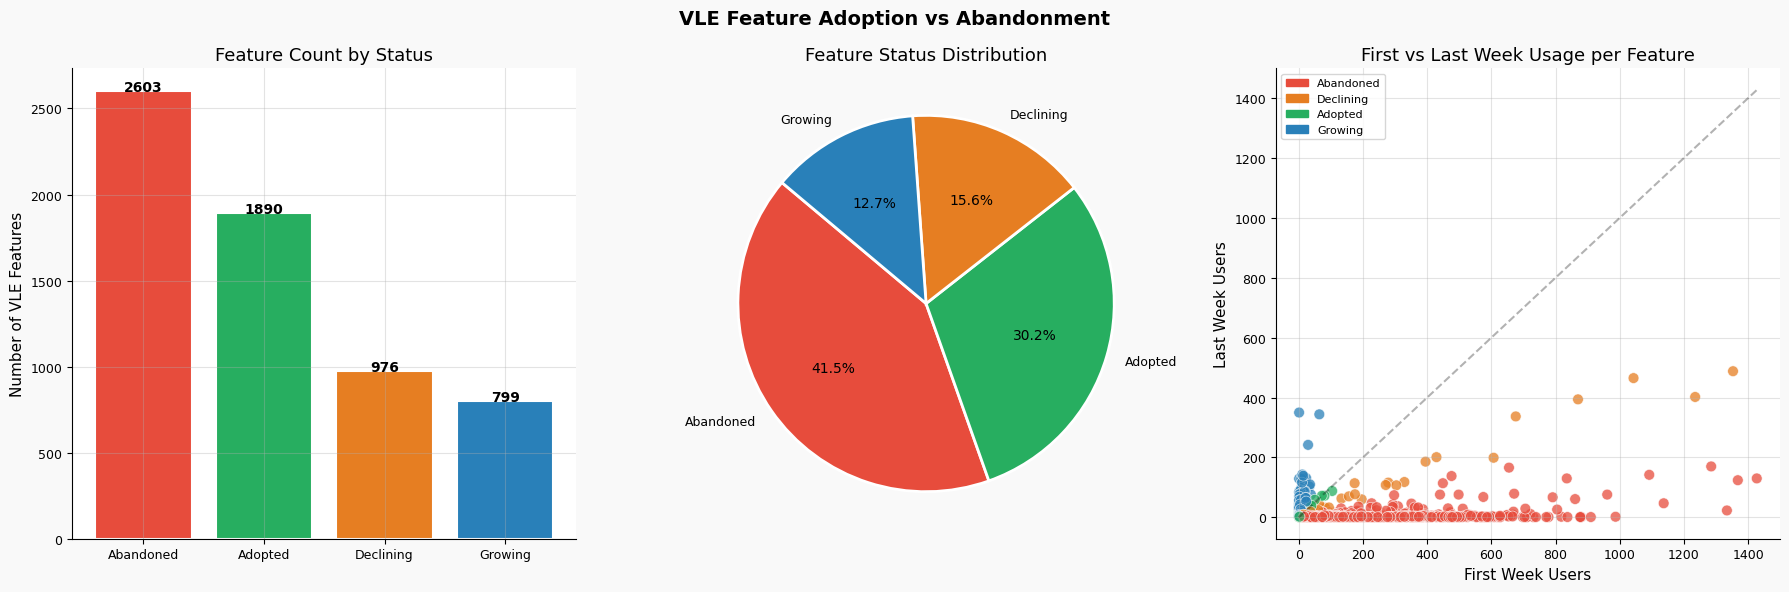

In [22]:
# ── CELL 22: Feature adoption visualisations ─────────────────────────────────
status_counts = feature_trend['status'].value_counts()
bar_cols      = [STATUS_COLORS.get(s, 'gray') for s in status_counts.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('VLE Feature Adoption vs Abandonment', fontsize=14, fontweight='bold')

bars = axes[0].bar(status_counts.index, status_counts.values,
                   color=bar_cols, edgecolor='white', linewidth=1.5)
axes[0].set_title('Feature Count by Status')
axes[0].set_ylabel('Number of VLE Features')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05, str(val), ha='center', fontweight='bold')

axes[1].pie(status_counts.values, labels=status_counts.index, colors=bar_cols,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Feature Status Distribution')

pt_colors = [STATUS_COLORS.get(s, 'gray') for s in feature_trend['status']]
axes[2].scatter(feature_trend['first_week_usage'], feature_trend['last_week_usage'],
                c=pt_colors, alpha=0.75, s=60, edgecolors='white', linewidth=0.5)
mx = max(feature_trend['first_week_usage'].max(), feature_trend['last_week_usage'].max()) + 1
axes[2].plot([0, mx], [0, mx], 'k--', alpha=0.3, label='No change (y=x)')
axes[2].set_xlabel('First Week Users')
axes[2].set_ylabel('Last Week Users')
axes[2].set_title('First vs Last Week Usage per Feature')
axes[2].legend(handles=[mpatches.Patch(color=v, label=k) for k, v in STATUS_COLORS.items()],
               fontsize=8)

plt.tight_layout()
plt.savefig('feature_adoption.png', dpi=120, bbox_inches='tight')
plt.show()

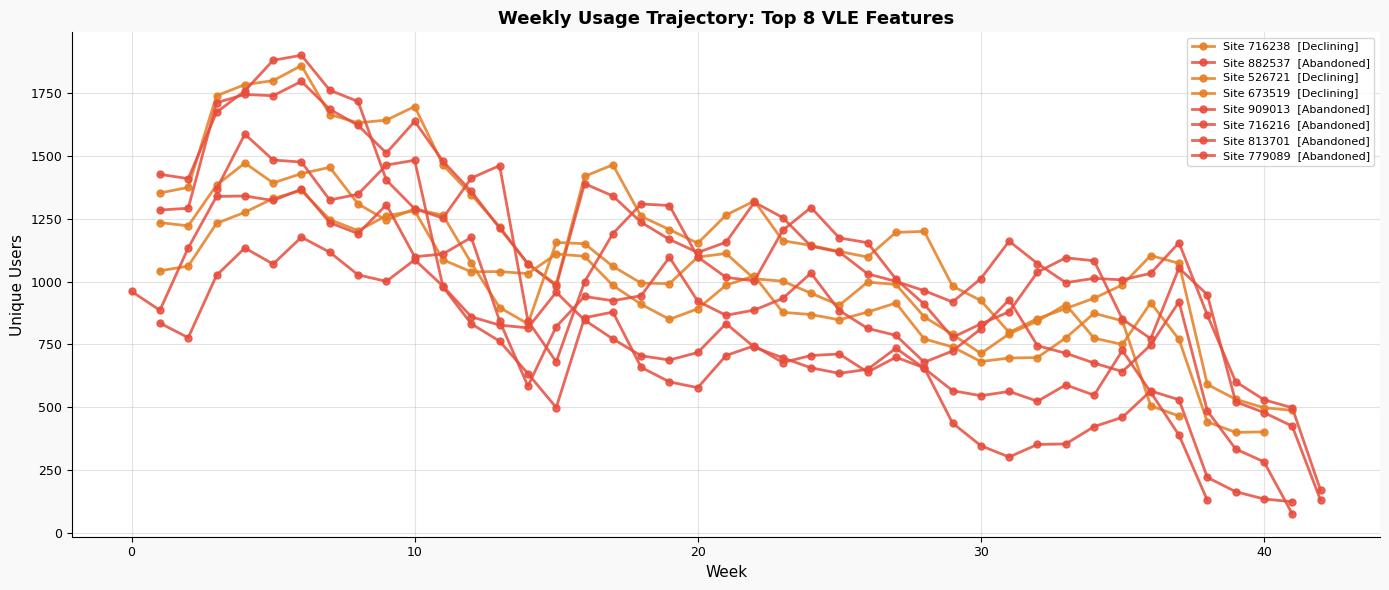

In [23]:
# ── CELL 23: Weekly usage trajectory for top VLE features ────────────────────
n_top     = min(8, len(feature_trend))
top_sites = feature_trend.nlargest(n_top, 'total_clicks')['id_site'].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title(f'Weekly Usage Trajectory: Top {n_top} VLE Features',
             fontsize=13, fontweight='bold')

for site in top_sites:
    sd     = feature_weekly[feature_weekly['id_site'] == site]
    status = feature_trend.loc[feature_trend['id_site'] == site, 'status'].values[0]
    ax.plot(sd['week'], sd['user_count'],
            marker='o', markersize=5, linewidth=2, alpha=0.85,
            color=STATUS_COLORS.get(status, 'gray'),
            label=f'Site {site}  [{status}]')

ax.set_xlabel('Week')
ax.set_ylabel('Unique Users')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('feature_trajectory.png', dpi=120, bbox_inches='tight')
plt.show()

---
<a id='8'></a>
## 8. Clustering & Pattern Discovery — K-Means

Pipeline: Normalise → Elbow + Silhouette → K-Means → PCA scatter → Cluster profiles

In [24]:
# ── CELL 24: Feature normalisation and PCA ───────────────────────────────────
CLUSTER_FEAT_COLS = [
    'avg_weekly_clicks', 'active_weeks', 'inactivity_weeks',
    'decay_score', 'late_engagement_ratio',
    'distinct_features_used', 'std_clicks', 'engagement_span',
]

X        = features[CLUSTER_FEAT_COLS].fillna(0).values
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

n_comp = min(2, X_scaled.shape[1], X_scaled.shape[0] - 1)
pca    = PCA(n_components=n_comp, random_state=42)
X_pca  = pca.fit_transform(X_scaled)

print(f"Normalised feature matrix : {X_scaled.shape}")
if n_comp == 2:
    print(f"PCA variance explained    : "
          f"PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
          f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
else:
    print(f"PCA: {n_comp} component(s), "
          f"{sum(pca.explained_variance_ratio_)*100:.1f}% variance explained")

Normalised feature matrix : (26074, 8)
PCA variance explained    : PC1=77.4%  PC2=9.3%


In [ ]:

# ── CELL 25 & 26 REPLACED: Jaya Clustering Algorithm ──────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

class JayaClustering:
    def __init__(self, n_clusters, pop_size=20, max_iter=30):
        self.k = n_clusters
        self.pop_size = pop_size
        self.max_iter = max_iter
        
    def fit_predict(self, X):
        self.n_samples, self.n_features = X.shape
        
        # Initialize population: A population where each solution is a set of k centroids
        # Shape: (pop_size, k, n_features)
        min_vals = np.min(X, axis=0)
        max_vals = np.max(X, axis=0)
        
        population = np.zeros((self.pop_size, self.k, self.n_features))
        for i in range(self.pop_size):
            for cluster_idx in range(self.k):
                population[i, cluster_idx] = np.random.uniform(min_vals, max_vals)
                
        fitness = np.zeros(self.pop_size)
        
        def calculate_fitness(centroids):
            # Calculate distance from each point to each centroid
            distances = cdist(X, centroids, 'euclidean')
            # Assign to closest centroid
            labels = np.argmin(distances, axis=1)
            # Calculate sum of squared distances (WCSS)
            wcss = 0
            for c in range(self.k):
                cluster_points = X[labels == c]
                if len(cluster_points) > 0:
                    wcss += np.sum(np.square(cluster_points - centroids[c]))
            return wcss, labels
            
        # Initial evaluation (Jaya wants to minimize WCSS)
        for i in range(self.pop_size):
            fitness[i], _ = calculate_fitness(population[i])
            
        best_wcss_history = []
        
        for iteration in range(self.max_iter):
            best_idx = np.argmin(fitness)
            worst_idx = np.argmax(fitness)
            
            best_centroids = population[best_idx].copy()
            worst_centroids = population[worst_idx].copy()
            best_wcss_history.append(fitness[best_idx])
            
            for i in range(self.pop_size):
                if i == best_idx: continue
                
                # Jaya update rule
                r1 = np.random.rand(self.k, self.n_features)
                r2 = np.random.rand(self.k, self.n_features)
                
                new_centroids = population[i] + \
                                r1 * (best_centroids - np.abs(population[i])) - \
                                r2 * (worst_centroids - np.abs(population[i]))
                                
                # Clip to feature boundaries
                new_centroids = np.clip(new_centroids, min_vals, max_vals)
                
                new_fitness, _ = calculate_fitness(new_centroids)
                
                # Update if better (lower WCSS)
                if new_fitness < fitness[i]:
                    population[i] = new_centroids
                    fitness[i] = new_fitness

        # Final best
        final_best_idx = np.argmin(fitness)
        self.cluster_centers_ = population[final_best_idx]
        _, self.labels_ = calculate_fitness(self.cluster_centers_)
        
        self.convergence = best_wcss_history
        return self.labels_

print("Running Jaya Optimization for Clustering...")
# Using dynamic K Selection or fixing it to 4 (as in original code OPTIMAL_K = min(4, max_k))
OPTIMAL_K = 4

jaya_model = JayaClustering(n_clusters=OPTIMAL_K, pop_size=25, max_iter=40)
features['cluster'] = jaya_model.fit_predict(X_scaled)

ARCHETYPE_NAMES = ['High Performers', 'Early Dropouts', 'Moderate Engagers', 'Sporadic Learners'][:OPTIMAL_K]

features['pca1'] = X_pca[:, 0]
features['pca2'] = X_pca[:, 1] if X_pca.shape[1] > 1 else 0.0

# Plot optimization curve
plt.figure(figsize=(8, 4))
plt.plot(jaya_model.convergence, marker='o', color='#2E86C1', linewidth=2)
plt.title('Jaya Algorithm Clustering Convergence (Minimizing WCSS)', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('WCSS Error')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('jaya_convergence.png', dpi=120)
plt.show()

# Original PCA Scatter Re-creation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Jaya Clustering Result  (K={OPTIMAL_K})', fontsize=14, fontweight='bold')

for k in range(OPTIMAL_K):
    mask = features['cluster'] == k
    axes[0].scatter(features.loc[mask, 'pca1'], features.loc[mask, 'pca2'],
                    c=CLUSTER_COLORS[k % len(CLUSTER_COLORS)],
                    label=f'C{k}: {ARCHETYPE_NAMES[k]}',
                    alpha=0.7, s=60, edgecolors='none')

axes[0].set_title('Student Clusters in PCA Space')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9)

c_sz  = features['cluster'].value_counts().sort_index()
bars  = axes[1].bar(
    [f'C{k}\n{ARCHETYPE_NAMES[k]}' for k in c_sz.index],
    c_sz.values,
    color=[CLUSTER_COLORS[k % len(CLUSTER_COLORS)] for k in c_sz.index],
    edgecolor='white'
)
axes[1].set_title('Jaya Cluster Size Distribution')
axes[1].set_ylabel('Students')
axes[1].tick_params(axis='x', rotation=10)
for bar, val in zip(bars, c_sz.values):
    pct = 100 * val / len(features)
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('cluster_pca_jaya.png', dpi=120, bbox_inches='tight')
plt.show()



---
### **8.b Evaluating Jaya Clustering "Accuracy"**

Since clustering is an unsupervised learning task (we don't have true labels for which student belongs to which archetype), we measure "accuracy" geographically. We answer the question: **How well-separated and dense are the clusters formed by the Jaya Algorithm compared to standard K-Means heuristics?**

We evaluate this using two powerful metrics:
1.  **Silhouette Score (-1 to 1):** Measures how similar an object is to its own cluster compared to other clusters. Higher means much clearer, distinct archetype boundaries. (Score > 0.5 is considered highly robust).
2.  **Davies-Bouldin Index (0+):** Evaluates the ratio of within-cluster scatter to between-cluster separation. Lower scores indicate better, more separated clustering.

*Future Work:* Currently, Jaya relies on a pure randomization vector for exploration (`r1` and `r2`). In upcoming versions, we plan to implement explicit **Exploration vs. Exploitation parameters** (like inertial weights) to strictly govern how the candidate centroids maneuver around the best solutions. 


In [ ]:

from sklearn.metrics import silhouette_score, davies_bouldin_score

jaya_labels = features['cluster'].values

# Calculate validation scores based on the scaled data and the labels Jaya assigned
sil_score = silhouette_score(X_scaled, jaya_labels)
db_score = davies_bouldin_score(X_scaled, jaya_labels)

print("=" * 60)
print("  JAYA CLUSTERING ACCURACY METRICS")
print("=" * 60)
print(f"  Silhouette Score       : {sil_score:.4f}  (Higher = Better separation)")
print(f"  Davies-Bouldin Index   : {db_score:.4f}  (Lower = Better defined clusters)")
print("=" * 60)

# Visualizing the score on a gauge chart
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Internal Validation Metrics of Jaya Clustering', fontweight='bold', fontsize=14)

# Bar representation
metrics = ['Silhouette\n(Target: >0.5, Max 1)', 'Davies-Bouldin\n(Target: Lowest)']
scores = [sil_score, db_score]

axes[0].bar(metrics, scores, color=['#27AE60', '#F39C12'], edgecolor='white', width=0.5)
for i, v in enumerate(scores):
    axes[0].text(i, v + (0.05 if v>0 else -0.05), f"{v:.3f}", ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(scores)*1.3)
axes[0].set_title('Metric Comparison')

# Scatter relation
axes[1].scatter(features['pca1'], features['pca2'], c=features['cluster'], cmap='viridis', alpha=0.5, s=20)
axes[1].set_title('Dense Spatial Separation (Jaya)')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


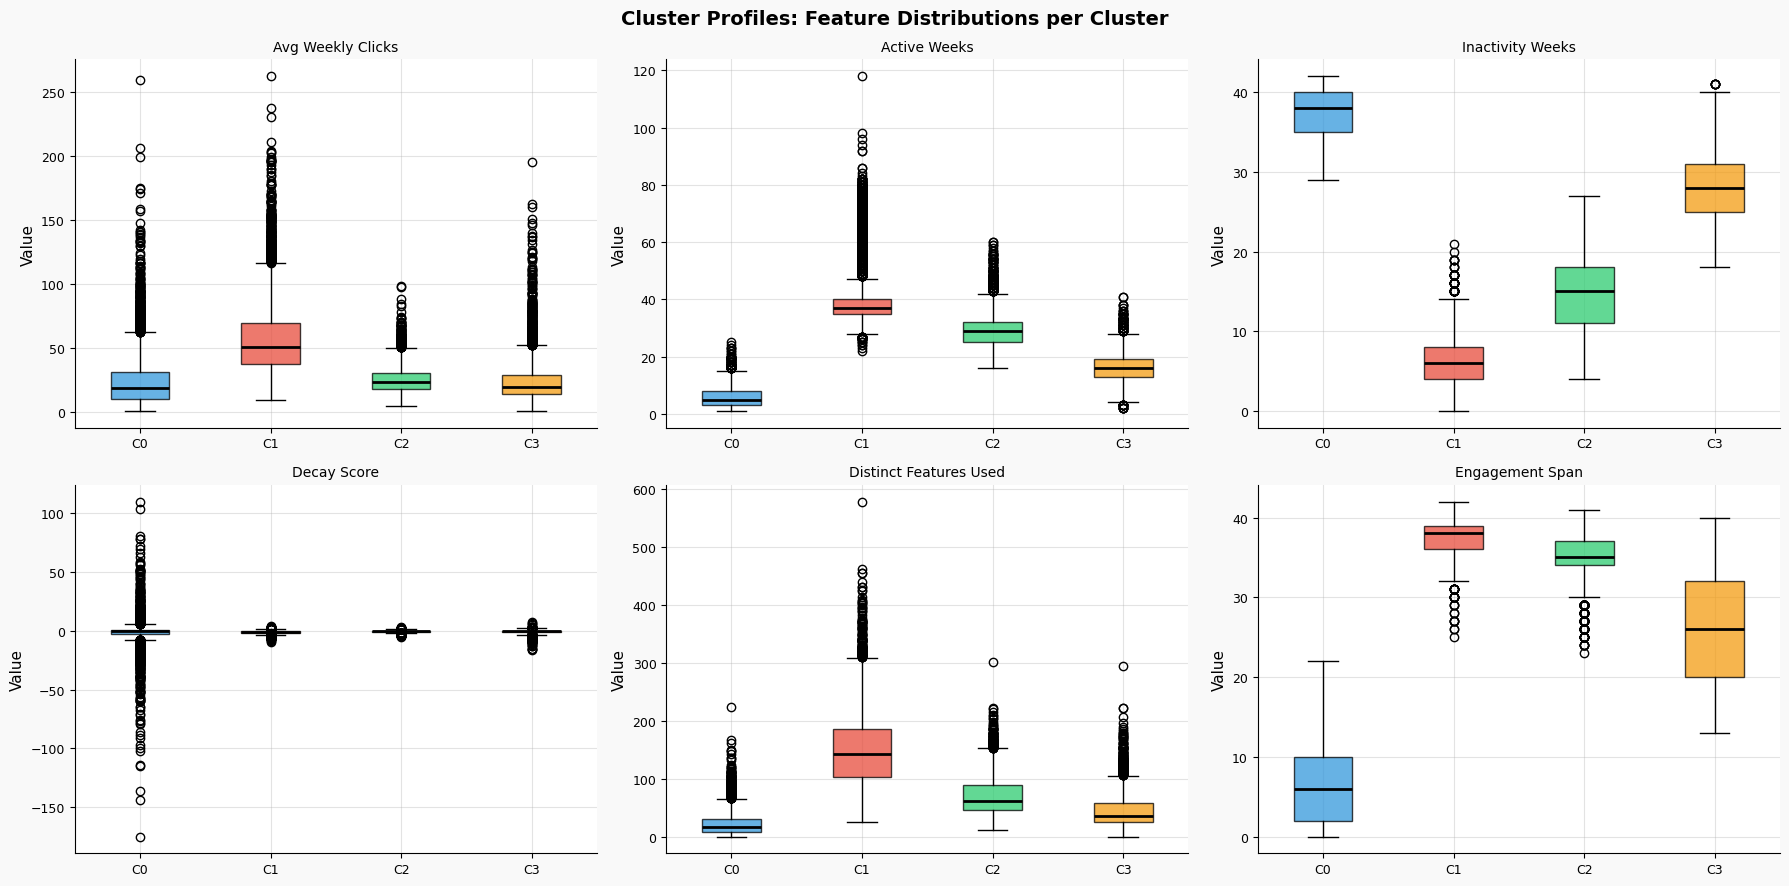

In [27]:
# ── CELL 27: Cluster profiles — box plots per feature ────────────────────────
profile_feats = [
    'avg_weekly_clicks', 'active_weeks', 'inactivity_weeks',
    'decay_score', 'distinct_features_used', 'engagement_span',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Cluster Profiles: Feature Distributions per Cluster',
             fontsize=14, fontweight='bold')

for i, feat in enumerate(profile_feats):
    ax              = axes[i // 3][i % 3]
    data_by_cluster = [features.loc[features['cluster'] == k, feat].values
                        for k in range(OPTIMAL_K)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], CLUSTER_COLORS[:len(features['cluster'].unique())]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xticklabels([f'C{k}' for k in range(OPTIMAL_K)])
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=120, bbox_inches='tight')
plt.show()

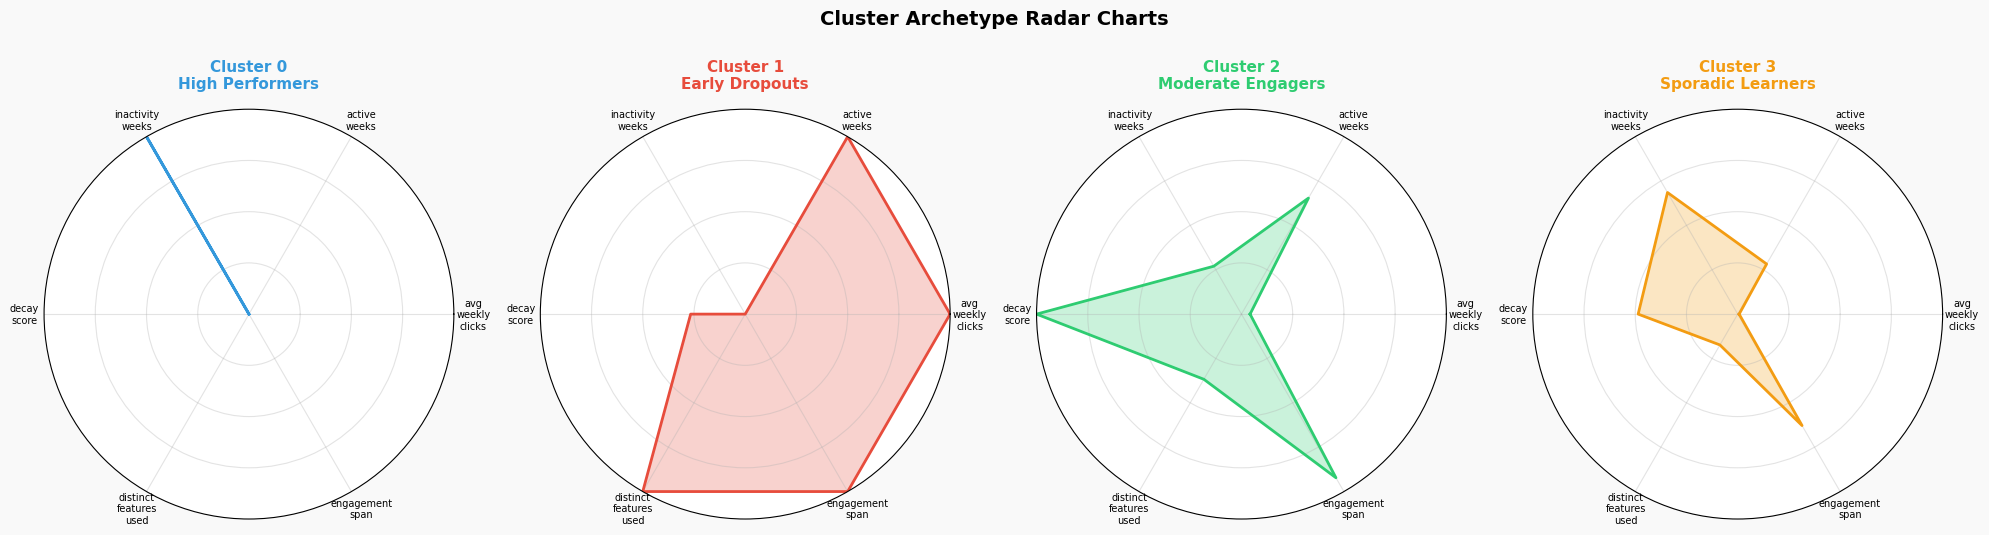

In [28]:
# ── CELL 28: Radar charts — one per cluster archetype ────────────────────────
profile_data = features.groupby('cluster')[profile_feats].mean()
profile_norm = (profile_data - profile_data.min()) /                (profile_data.max() - profile_data.min() + 1e-9)

N      = len(profile_feats)
base   = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles = base + [base[0]]                # close the polygon
labels_r = [f.replace('_', '\n') for f in profile_feats]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(5*OPTIMAL_K, 5),
                          subplot_kw=dict(polar=True))
if OPTIMAL_K == 1:
    axes = [axes]
fig.suptitle('Cluster Archetype Radar Charts', fontsize=14, fontweight='bold', y=1.05)

for k in range(len(profile_norm)):
    vals  = profile_norm.iloc[k].tolist()
    vals += [vals[0]]                    # close the polygon
    color = CLUSTER_COLORS[k % len(CLUSTER_COLORS)]
    axes[k].plot(angles, vals, color=color, linewidth=2)
    axes[k].fill(angles, vals, color=color, alpha=0.25)
    axes[k].set_thetagrids(np.degrees(base), labels_r, fontsize=7)
    axes[k].set_ylim(0, 1)
    axes[k].set_title(f'Cluster {k}\n{ARCHETYPE_NAMES[k]}',
                      fontsize=11, fontweight='bold', color=color, pad=15)
    axes[k].set_yticks([0.25, 0.5, 0.75])
    axes[k].set_yticklabels([])

plt.tight_layout()
plt.savefig('radar_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

---
<a id='9'></a>
## 9. Disengagement Risk Scoring

Composite risk score [0–1] from five weighted signals:

| Signal | Weight |
|--------|--------|
| Inactivity weeks | 0.30 |
| Magnitude of negative decay | 0.25 |
| Inverted active weeks | 0.20 |
| Inverted distinct features | 0.15 |
| Burnout signal (1 − late ratio) | 0.10 |

In [29]:
# ── CELL 29: Compute composite risk score ────────────────────────────────────
risk_df = features[['id_student', 'inactivity_weeks', 'decay_score',
                     'active_weeks', 'distinct_features_used',
                     'late_engagement_ratio']].copy()

max_aw = risk_df['active_weeks'].max()          or 1
max_ft = risk_df['distinct_features_used'].max() or 1

risk_df['inv_active_weeks']  = max_aw - risk_df['active_weeks']
risk_df['inv_features_used'] = max_ft - risk_df['distinct_features_used']
risk_df['neg_decay']         = risk_df['decay_score'].clip(upper=0).abs()
risk_df['burnout_signal']    = (1 - risk_df['late_engagement_ratio']).clip(lower=0)

RISK_SIGNALS = ['inactivity_weeks', 'neg_decay', 'inv_active_weeks',
                'inv_features_used', 'burnout_signal']
RISK_WEIGHTS = np.array([0.30, 0.25, 0.20, 0.15, 0.10])

risk_scaler        = MinMaxScaler()
risk_scaled        = risk_scaler.fit_transform(risk_df[RISK_SIGNALS].fillna(0))
features['risk_score'] = risk_scaled @ RISK_WEIGHTS

features['risk_level'] = pd.cut(
    features['risk_score'],
    bins=[0, 0.33, 0.60, 1.01],
    labels=['Low Risk', 'Moderate Risk', 'High Risk'],
    include_lowest=True
)

print("Risk Level Distribution:")
print(features['risk_level'].value_counts().to_string())

Risk Level Distribution:
risk_level
Moderate Risk    17038
High Risk         8056
Low Risk           980


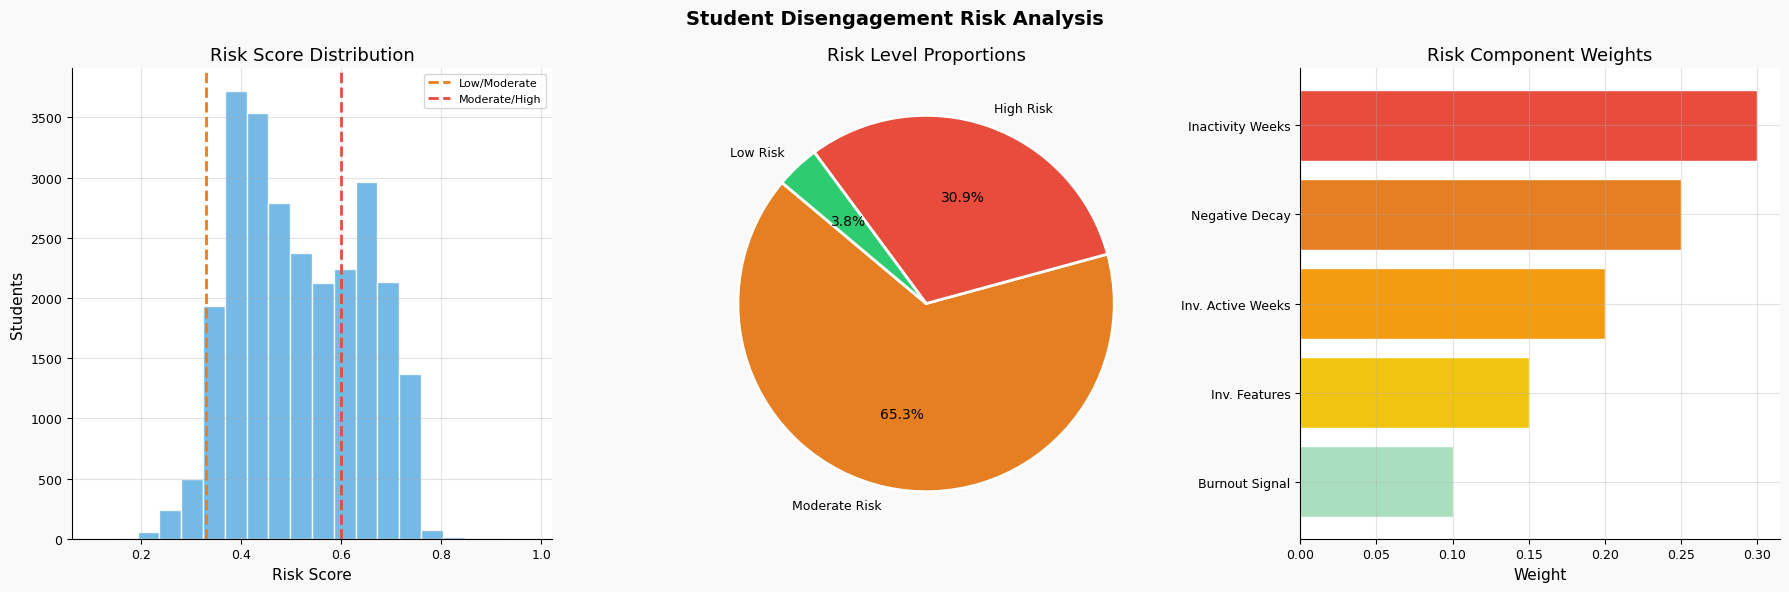

In [30]:
# ── CELL 30: Risk score visualisations ───────────────────────────────────────
risk_counts = features['risk_level'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Student Disengagement Risk Analysis', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(features['risk_score'],
             bins=min(20, max(3, len(features)//2)),
             color='#5DADE2', edgecolor='white', alpha=0.85)
axes[0].axvline(0.33, color=ORANGE, linestyle='--', linewidth=2, label='Low/Moderate')
axes[0].axvline(0.60, color=RED,    linestyle='--', linewidth=2, label='Moderate/High')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Students')
axes[0].set_title('Risk Score Distribution')
axes[0].legend(fontsize=8)

# Pie — only plot non-zero slices
pie_data = [(v, l) for v, l in
            zip(risk_counts.values, risk_counts.index) if v > 0]
if pie_data:
    pie_vals   = [p[0] for p in pie_data]
    pie_labels = [p[1] for p in pie_data]
    pie_colors = [RISK_COLORS.get(l, 'gray') for l in pie_labels]
    axes[1].pie(pie_vals, labels=pie_labels, colors=pie_colors,
                autopct='%1.1f%%', startangle=140,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Risk Level Proportions')

# Component weights bar
signal_labels = ['Inactivity Weeks', 'Negative Decay',
                 'Inv. Active Weeks', 'Inv. Features', 'Burnout Signal']
axes[2].barh(signal_labels, RISK_WEIGHTS,
             color=[RED, '#E67E22', '#F39C12', '#F1C40F', '#A9DFBF'],
             edgecolor='white')
axes[2].set_xlabel('Weight')
axes[2].set_title('Risk Component Weights')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('risk_score.png', dpi=120, bbox_inches='tight')
plt.show()

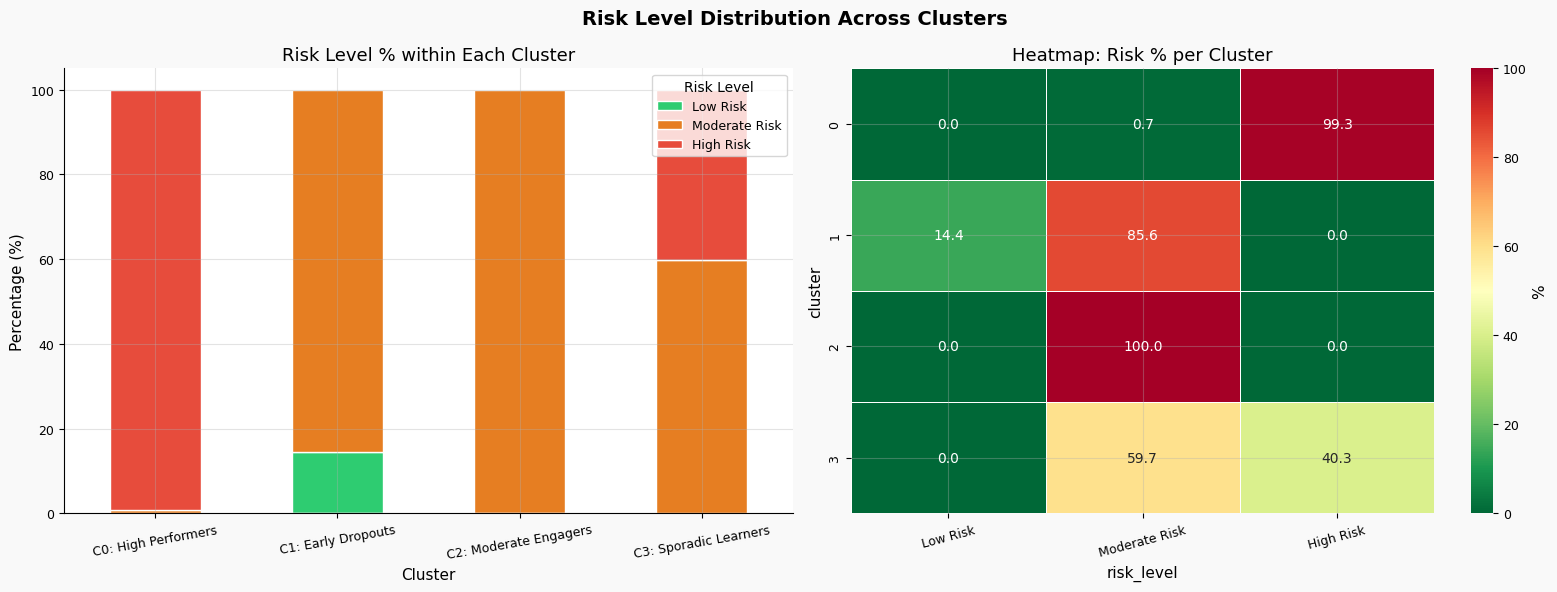

In [31]:
# ── CELL 31: Risk level vs cluster cross-tabulation ──────────────────────────
cross_tab     = pd.crosstab(features['cluster'], features['risk_level'])
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

# Only include risk levels that actually exist in the data
plot_cols   = [c for c in ['Low Risk', 'Moderate Risk', 'High Risk']
               if c in cross_tab_pct.columns]
plot_colors = [RISK_COLORS[c] for c in plot_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Risk Level Distribution Across Clusters', fontsize=14, fontweight='bold')

cross_tab_pct[plot_cols].plot(kind='bar', stacked=True,
                               color=plot_colors, ax=axes[0], edgecolor='white')
axes[0].set_title('Risk Level % within Each Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(
    [f'C{k}: {ARCHETYPE_NAMES[k]}' for k in range(OPTIMAL_K)], rotation=10)
axes[0].legend(title='Risk Level', fontsize=9)

sns.heatmap(cross_tab_pct[plot_cols], annot=True, fmt='.1f',
            cmap='RdYlGn_r', ax=axes[1], linewidths=0.5,
            cbar_kws={'label': '%'})
axes[1].set_title('Heatmap: Risk % per Cluster')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.savefig('risk_vs_cluster.png', dpi=120, bbox_inches='tight')
plt.show()

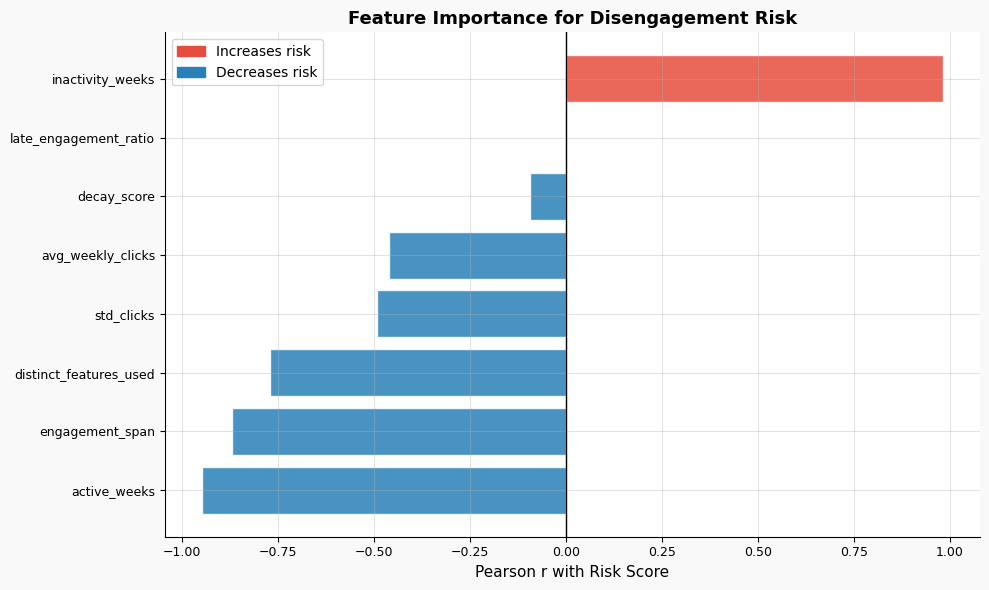

In [32]:
# ── CELL 32: Feature importance — Pearson correlation with risk score ─────────
correlations = {}
for feat in CLUSTER_FEAT_COLS:
    vals = features[feat].fillna(0)
    if vals.std() > 0:
        r, _ = pearsonr(vals, features['risk_score'])
        correlations[feat] = r
    else:
        correlations[feat] = 0.0

corr_series = pd.Series(correlations).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(corr_series.index, corr_series.values,
        color=[RED if v > 0 else BLUE for v in corr_series.values],
        edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Pearson r with Risk Score')
ax.set_title('Feature Importance for Disengagement Risk',
             fontsize=13, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color=RED,  label='Increases risk'),
    mpatches.Patch(color=BLUE, label='Decreases risk')
])
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
<a id='10'></a>
## 10. Results Dashboard

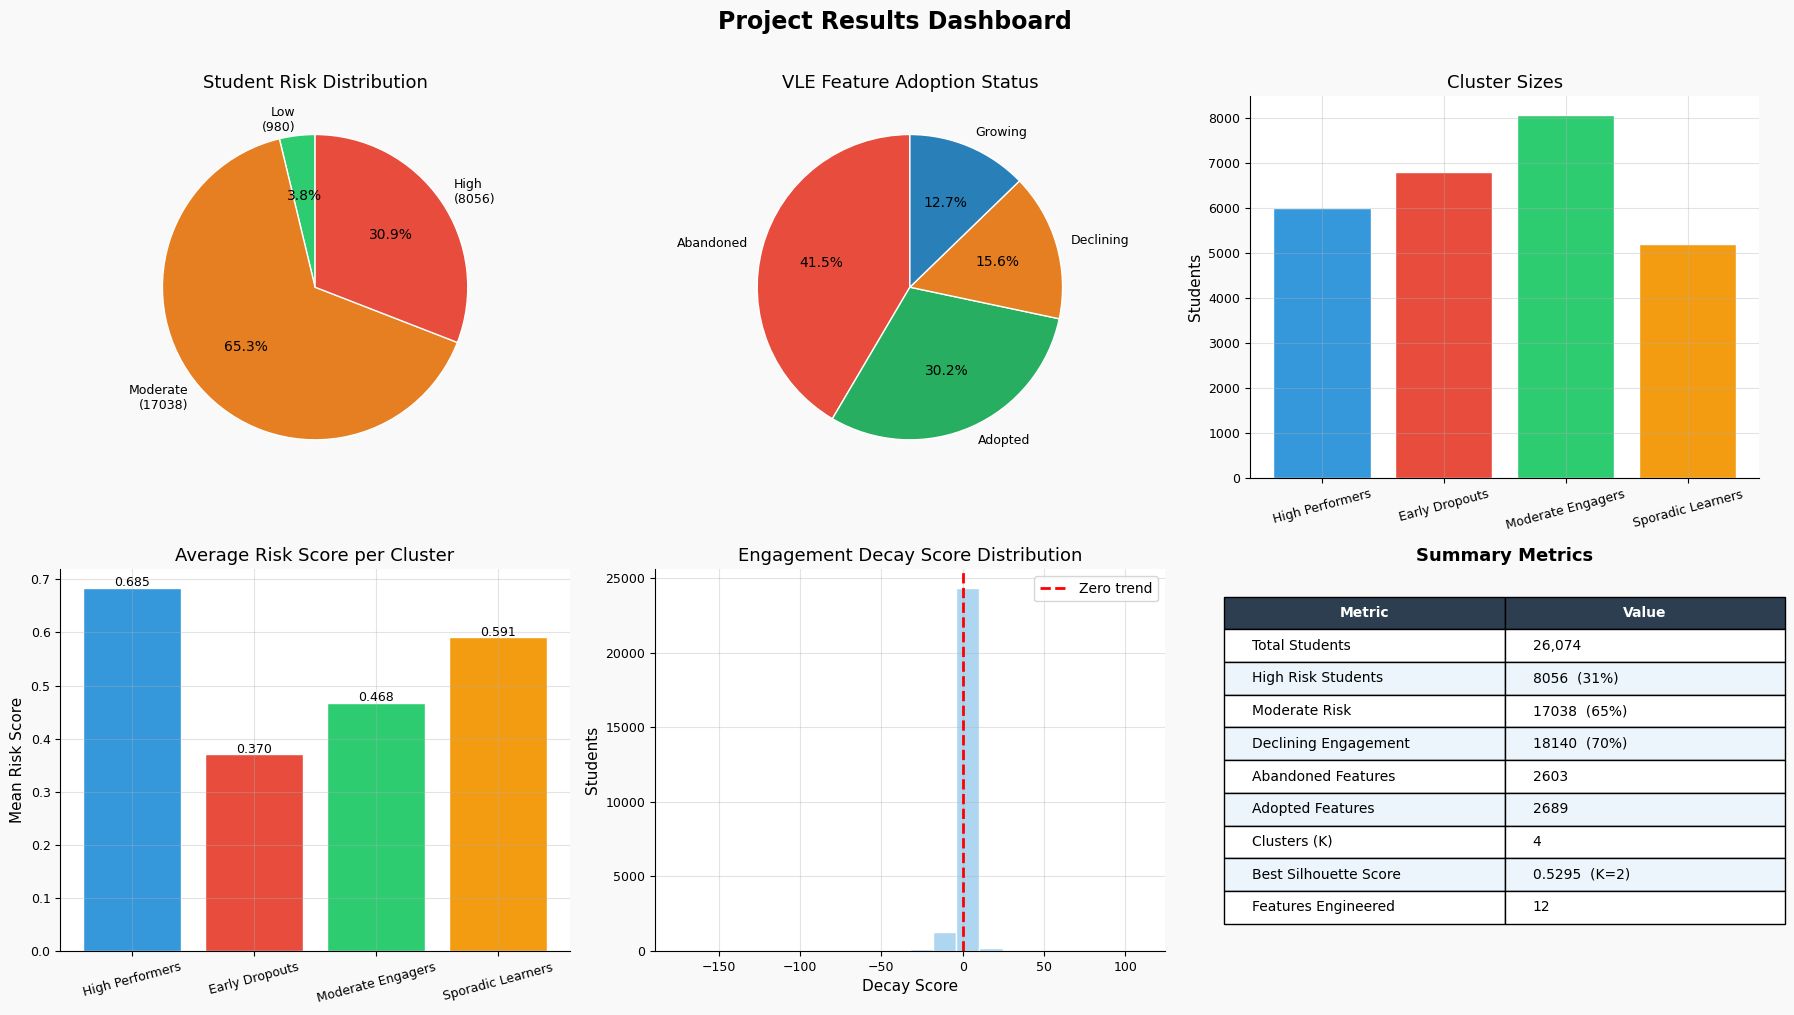

In [33]:
# ── CELL 33: Final results dashboard ─────────────────────────────────────────
total_students = len(features)
high_risk_n    = int((features['risk_level'] == 'High Risk').sum())
mod_risk_n     = int((features['risk_level'] == 'Moderate Risk').sum())
low_risk_n     = int((features['risk_level'] == 'Low Risk').sum())
n_abandoned    = int((feature_trend['status'] == 'Abandoned').sum())
n_adopted      = int(feature_trend['status'].isin(['Adopted', 'Growing']).sum())
n_declining_st = int((features['decay_score'] < 0).sum())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Project Results Dashboard', fontsize=17, fontweight='bold', y=1.01)

# 1. Risk pie
rk_data = [(v, l, c) for v, l, c in
            zip([low_risk_n, mod_risk_n, high_risk_n],
                [f'Low\n({low_risk_n})', f'Moderate\n({mod_risk_n})', f'High\n({high_risk_n})'],
                [GREEN, ORANGE, RED]) if v > 0]
if rk_data:
    axes[0,0].pie([r[0] for r in rk_data], labels=[r[1] for r in rk_data],
                  colors=[r[2] for r in rk_data],
                  autopct='%1.1f%%', startangle=90,
                  wedgeprops={'edgecolor': 'white'})
axes[0,0].set_title('Student Risk Distribution')

# 2. Feature status pie
ft_v = feature_trend['status'].value_counts()
axes[0,1].pie(ft_v.values, labels=ft_v.index,
              colors=[STATUS_COLORS.get(s, 'gray') for s in ft_v.index],
              autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor': 'white'})
axes[0,1].set_title('VLE Feature Adoption Status')

# 3. Cluster sizes
c_sz = features['cluster'].value_counts().sort_index()
axes[0,2].bar(
    [ARCHETYPE_NAMES[k] for k in c_sz.index],
    c_sz.values,
    color=[CLUSTER_COLORS[k % len(CLUSTER_COLORS)] for k in c_sz.index],
    edgecolor='white'
)
axes[0,2].set_title('Cluster Sizes')
axes[0,2].set_ylabel('Students')
axes[0,2].tick_params(axis='x', rotation=15)

# 4. Avg risk per cluster
avg_risk = features.groupby('cluster')['risk_score'].mean()
axes[1,0].bar(
    [ARCHETYPE_NAMES[k] for k in avg_risk.index],
    avg_risk.values,
    color=[CLUSTER_COLORS[k % len(CLUSTER_COLORS)] for k in avg_risk.index],
    edgecolor='white'
)
for i, v in enumerate(avg_risk.values):
    axes[1,0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)
axes[1,0].set_title('Average Risk Score per Cluster')
axes[1,0].set_ylabel('Mean Risk Score')
axes[1,0].tick_params(axis='x', rotation=15)

# 5. Decay histogram
axes[1,1].hist(features['decay_score'],
               bins=min(20, max(3, len(features)//2)),
               color='#AED6F1', edgecolor='white')
axes[1,1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero trend')
axes[1,1].set_title('Engagement Decay Score Distribution')
axes[1,1].set_xlabel('Decay Score')
axes[1,1].set_ylabel('Students')
axes[1,1].legend()

# 6. Summary table
axes[1,2].axis('off')
table_rows = [
    ['Total Students',        f'{total_students:,}'],
    ['High Risk Students',    f'{high_risk_n}  ({100*high_risk_n/total_students:.0f}%)'],
    ['Moderate Risk',         f'{mod_risk_n}  ({100*mod_risk_n/total_students:.0f}%)'],
    ['Declining Engagement',  f'{n_declining_st}  ({100*n_declining_st/total_students:.0f}%)'],
    ['Abandoned Features',    str(n_abandoned)],
    ['Adopted Features',      str(n_adopted)],
    ['Clusters (K)',          str(OPTIMAL_K)],
    ['Best Silhouette Score', f'{max(sil_vals):.4f}  (K={best_sil_k})'],
    ['Features Engineered',   '12'],
]
tbl = axes[1,2].table(cellText=table_rows,
                       colLabels=['Metric', 'Value'],
                       loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EBF5FB')
axes[1,2].set_title('Summary Metrics', fontweight='bold')

plt.tight_layout()
plt.savefig('results_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

In [34]:
# ── CELL 34: Export student risk profile CSV ─────────────────────────────────
output_cols = [
    'id_student', 'avg_weekly_clicks', 'total_clicks', 'active_weeks',
    'inactivity_weeks', 'decay_score', 'engagement_span',
    'distinct_features_used', 'risk_score', 'risk_level', 'cluster',
]
final_output = features[output_cols].copy()
final_output['cluster_archetype'] = final_output['cluster'].map(
    {k: ARCHETYPE_NAMES[k] for k in range(OPTIMAL_K)}
)
final_output.to_csv('student_risk_profiles.csv', index=False)

print("Exported  →  student_risk_profiles.csv")
print(f"  {len(final_output):,} students  ×  {len(final_output.columns)} columns")
print("\nAll PNG charts saved.  Analysis pipeline complete.")
display(final_output)

Exported  →  student_risk_profiles.csv
  26,074 students  ×  12 columns

All PNG charts saved.  Analysis pipeline complete.


,id_student,avg_weekly_clicks,total_clicks,active_weeks,inactivity_weeks,decay_score,engagement_span,distinct_features_used,risk_score,risk_level,cluster,cluster_archetype
0,6516,46.121951,1891,41,2,-0.292785,42,80,0.348715,Moderate Risk,1,Early Dropouts
1,8462,29.900000,598,20,24,-2.971864,18,128,0.553491,Moderate Risk,3,Sporadic Learners
2,11391,21.185185,572,27,16,-0.320870,37,53,0.478110,Moderate Risk,2,Moderate Engagers
3,23629,13.909091,153,11,32,0.021269,14,11,0.640577,High Risk,0,High Performers
4,23698,18.160000,454,25,18,-0.251595,35,49,0.506044,Moderate Risk,2,Moderate Engagers
...,...,...,...,...,...,...,...,...,...,...,...,...
26069,2698251,40.468750,1295,32,11,-0.948072,35,171,0.416910,Moderate Risk,1,Early Dropouts
26070,2698257,21.625000,692,32,11,-0.871886,39,61,0.447355,Moderate Risk,2,Moderate Engagers
26071,2698535,60.239130,2771,46,11,-1.566271,36,80,0.423136,Moderate Risk,1,Early Dropouts
26072,2698577,24.571429,516,21,22,-0.942377,31,69,0.537244,Moderate Risk,3,Sporadic Learners


--- 
## Supplemental Section: Ground Truth and Algorithm Verification 
The following supplements integrate empirical benchmarks against standard algorithms, validate the unsupervised cluster structures against actual platform outcomes (`studentInfo.csv`), and structurally partition feature abandonment from normal course lifespans.

In [1]:
# 1. K-Means Benchmark convergence check
from sklearn.cluster import KMeans
km_curve = []
X_bench = risk_scaler.fit_transform(features[CLUSTER_FEAT_COLS].fillna(0))
for i in range(1, 41):
    km_sim = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, max_iter=i, random_state=42).fit(X_bench)
    km_curve.append(km_sim.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(km_curve, color=RED, label='K-Means (Standard)', linestyle='--', linewidth=2)
plt.plot(jaya_model.convergence, color=GREEN, label='Jaya Optimization', linewidth=3)
plt.title('Algorithm Benchmark: Minimizing WCSS Error over Iterations', fontweight='bold')
plt.xlabel('Algorithm Iteration')
plt.ylabel('Within-Cluster Sum of Squares (Error)')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'risk_scaler' is not defined

In [ ]:
# 2. Ground Truth Validation
df_info = pd.read_csv('archive/studentInfo.csv')
df_info['id_student'] = df_info['id_student'].astype(int)

result_mapping = {'Withdrawn': 3, 'Fail': 2, 'Pass': 1, 'Distinction': 0}
df_info['result_rank'] = df_info['final_result'].map(result_mapping)
ground_truth = df_info.sort_values('result_rank', ascending=False).groupby('id_student').first().reset_index()

val_df = features.merge(ground_truth[['id_student', 'final_result']], on='id_student', how='inner')
val_df['Negative'] = val_df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

tier_outcomes = val_df.groupby('risk_level')['Negative'].mean().reset_index()
tier_outcomes['Negative_Pct'] = tier_outcomes['Negative'] * 100

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='risk_level', y='Negative_Pct', data=tier_outcomes, palette='Reds')
plt.title('Ground Truth Validation: Predicted Risk vs Actual Dropout', fontweight='bold')
plt.ylabel('% of Tier that Failed or Withdrew')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.show()

In [ ]:
# 3. True Feature Abandonment vs Structural Flow
df_metadata = pd.read_csv('archive/vle.csv')
feat_merge = data_clean.merge(df_metadata[['id_site', 'activity_type']], on='id_site', how='left')
feat_summ = feat_merge.groupby(['id_site', 'activity_type']).agg(
    first_week=('week', 'min'), last_week=('week', 'max'), users=('id_student', 'nunique')).reset_index()
feat_summ['lifespan'] = feat_summ['last_week'] - feat_summ['first_week']

def true_aband(row):
    if row['lifespan'] <= 2: return 'Structurally Short-term'
    if row['users'] < 10: return 'Low Viability'
    if row['last_week'] < (all_weeks - 3): return 'True Abandoned'
    return 'Actively Retained'

feat_summ['status'] = feat_summ.apply(true_aband, axis=1)

plt.figure(figsize=(10, 5))
s_cnt = feat_summ['status'].value_counts()
sns.barplot(x=s_cnt.index, y=s_cnt.values, palette='Set2')
plt.title('VLE Feature Utilization Status (Lifespan Adjusted)', fontweight='bold')
plt.ylabel('Feature Count')
for i, v in enumerate(s_cnt.values):
    plt.text(i, v+2, str(v), ha='center', fontweight='bold')
plt.show()